<a href="https://colab.research.google.com/github/mashrur-rahman-fahim/DA-Dhaka-air-quality-prediction/blob/main/dhaka_pm25.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Dhaka PM2.5 — short-term air quality forecasting

## Part 1: Explore the data

We want to predict how polluted Dhaka's air will be in the next hour.

**This notebook only looks. It decides nothing and changes nothing.**

That order is deliberate. If we clean first, we clean based on assumptions.
If we look first, every later decision — which columns to keep, which to throw
away, how to split, which model — is backed by something we actually saw.

At the end there is a list of the decisions this exploration opens up. We make
those in Part 2.

> **This is the only notebook for the project.** Part 2 and Part 3 get
> appended to the bottom of this same file, so the Spark session and every
> variable computed above stay alive as the work grows.

> **Runtime:** use **CPU** (Runtime -> Change runtime type -> CPU).
> Spark's ML library has no GPU support, so a GPU here does nothing.

Every code cell has a description above it explaining what it does and what to
look for in the output.

---
# Setup

## Step 1 — Check Python and Java

PySpark is only a thin Python wrapper. The real work happens in a **Java**
program running beside your notebook. So both have to be present.

This cell prints versions. It changes nothing.

In [1]:
import sys
import subprocess

print("Python:", sys.version.split()[0])

# Java writes its version to stderr rather than stdout, hence .stderr below
java = subprocess.run(["java", "-version"], capture_output=True, text=True)
print("Java  :", java.stderr.strip().splitlines()[0] if java.stderr else "NOT FOUND")

Python: 3.13.15
Java  : openjdk version "21.0.12" 2026-07-21


## Step 2 — Install PySpark

About 300 MB, so we skip it if it is already installed.

Version **4.0.4** is chosen deliberately: Colab now runs Python 3.13, which the
older PySpark 3.5 does not support, and Colab preinstalls a package that expects
PySpark 4.0.x. Anything else produces either a crash or a conflict warning.

Takes 1-2 minutes the first time.

In [2]:
try:
    import pyspark
    print("PySpark already installed:", pyspark.__version__)
except ImportError:
    print("Installing PySpark, this takes a minute...")
    !pip install -q pyspark==4.0.4
    import pyspark
    print("Installed PySpark:", pyspark.__version__)

PySpark already installed: 4.0.4


## Step 3 — Fix the random seed

Anything that involves chance — shuffling, sampling, the random starting points
inside a model — will give slightly different answers each run unless we pin it
down.

We set one `SEED` value here and reuse it everywhere for the rest of the
notebook.

**Why this matters for the report:** when a number changes between two runs, you
need to know whether it changed because you improved something or because the
dice landed differently. With a fixed seed, only the first is possible.

In [3]:
import random
import numpy as np

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("random seed fixed at", SEED)
print("pass seed=SEED to anything that samples, splits or trains")

random seed fixed at 42
pass seed=SEED to anything that samples, splits or trains


## Step 4 — Download the data

The readings come from the **US Embassy in Dhaka**. It has measured PM2.5 every
hour since 2016 and publishes the results through the AirNow programme.

One CSV per year, ten files, about 8 MB in total. The data is public — no
account, no API key.

Note: most tutorials point at `dosairnowdata.org`, which no longer exists. The
address below is the live storage that the EPA's own embassy map reads from.

Re-running this cell is free — it skips files already downloaded.

In [4]:
import os
import urllib.request

BASE_URL = ("https://s3-us-west-1.amazonaws.com/files.airnowtech.org"
            "/airnow/EmbassyHistorical/Dhaka")
FOLDER = "data"

os.makedirs(FOLDER, exist_ok=True)

for year in range(2016, 2026):
    filename = f"Dhaka_PM2.5_{year}_YTD.csv"
    filepath = os.path.join(FOLDER, filename)

    if os.path.exists(filepath):
        print("already have:", filename)
    else:
        urllib.request.urlretrieve(f"{BASE_URL}/{year}/{filename}", filepath)
        print("downloaded  :", filename)

downloaded  : Dhaka_PM2.5_2016_YTD.csv
downloaded  : Dhaka_PM2.5_2017_YTD.csv
downloaded  : Dhaka_PM2.5_2018_YTD.csv
downloaded  : Dhaka_PM2.5_2019_YTD.csv
downloaded  : Dhaka_PM2.5_2020_YTD.csv
downloaded  : Dhaka_PM2.5_2021_YTD.csv
downloaded  : Dhaka_PM2.5_2022_YTD.csv
downloaded  : Dhaka_PM2.5_2023_YTD.csv
downloaded  : Dhaka_PM2.5_2024_YTD.csv
downloaded  : Dhaka_PM2.5_2025_YTD.csv


## Step 5 — Read the raw text before touching Spark

Always look at the actual characters in the file first. It takes ten seconds and
prevents a long chain of wrong assumptions.

**Look for three things in the output:**

1. Column names contain spaces and dots — `Raw Conc.`, `QC Name`. Awkward in
   Spark, so in Step 6 we give them clean names.
2. The date is written in **12-hour** form with `AM`/`PM`.
3. The first data rows say `-999.0` and `Missing`. That is the station's code
   for *no reading*. Not a measurement.

In [5]:
with open("data/Dhaka_PM2.5_2016_YTD.csv") as f:
    for i in range(4):
        print(f.readline().strip())
        print()

Site,Parameter,Date (LT),Year,Month,Day,Hour,NowCast Conc.,AQI,AQI Category,Raw Conc.,Conc. Unit,Duration,QC Name

Dhaka,PM2.5 - Principal,2016-01-01 01:00 AM,2016,01,01,01,-999.0,-999,N/A,-999.0,UG/M3,1 Hr,Missing

Dhaka,PM2.5 - Principal,2016-01-01 02:00 AM,2016,01,01,02,-999.0,-999,N/A,-999.0,UG/M3,1 Hr,Missing

Dhaka,PM2.5 - Principal,2016-01-01 03:00 AM,2016,01,01,03,-999.0,-999,N/A,-999.0,UG/M3,1 Hr,Missing



## Step 6 — Start Spark

A `SparkSession` is the single entry point to everything in Spark.

| Setting | Meaning |
|---|---|
| `master("local[*]")` | Run here, use every CPU core |
| `appName(...)` | A label that only shows up in logs |
| `timeZone("UTC")` | Not the mistake it looks like — see the note below |

First run takes ~20 seconds while the Java process boots.

**Why UTC, and not `Asia/Dhaka`?** The readings are already Dhaka wall-clock
times and we never convert between zones, so these timestamps are really just
labels — "the 3pm reading" — not moments on a world clock.

Setting the zone to `Asia/Dhaka` looks more correct and quietly breaks things.
Spark would print times in Dhaka time, but when Python pulls a timestamp out of
Spark it converts using the machine's own zone, which on Colab is UTC. The same
moment would then print as two different times, six hours apart, depending on
which way you asked for it. Choosing UTC makes every route agree.

In [6]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (SparkSession.builder
         .appName("dhaka-pm25-explore")
         .master("local[*]")
         .config("spark.sql.session.timeZone", "UTC")
         # A fixed partition count keeps the order additions happen in stable,
         # so repeated runs agree to the last decimal place.
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())

# Spark is very chatty by default. Show real errors only.
spark.sparkContext.setLogLevel("ERROR")

print("Spark running, version", spark.version)

Spark running, version 4.0.4


## Step 7 — Tell Spark the column types

Spark can guess types by scanning the file (`inferSchema=True`). We write them
out by hand instead, for two reasons:

1. Guessing means reading all the data twice.
2. The streaming part of this project later **refuses** to guess. So this has to
   be written eventually — better once, now.

A useful side effect: because we supply the names, Spark ignores the messy
header in the file and uses ours. No renaming step needed later.

In [7]:
from pyspark.sql.types import (
    StructType, StructField, StringType, IntegerType, DoubleType,
)

# Order MUST match the column order in the CSV.
schema = StructType([
    StructField("site",         StringType()),    # expect: always "Dhaka"
    StructField("parameter",    StringType()),    # expect: always "PM2.5 - Principal"
    StructField("date_text",    StringType()),    # e.g. "2016-01-01 01:00 AM"
    StructField("year",         IntegerType()),
    StructField("month",        IntegerType()),
    StructField("day",          IntegerType()),
    StructField("hour",         IntegerType()),   # 0 to 23
    StructField("nowcast",      DoubleType()),    # AirNow's smoothed value
    StructField("aqi",          IntegerType()),   # Air Quality Index, 0-500
    StructField("aqi_category", StringType()),    # "Good" ... "Hazardous"
    StructField("pm25",         DoubleType()),    # the reading we care about
    StructField("unit",         StringType()),    # expect: always "UG/M3"
    StructField("duration",     StringType()),    # expect: always "1 Hr"
    StructField("qc",           StringType()),    # "Valid" / "Missing" / ...
])

print(len(schema.fields), "columns defined")

14 columns defined


## Step 8 — Read all ten files as one table

Point Spark at the **folder**, not a file, and it treats every CSV inside as one
table.

`.cache()` keeps the result in memory. Without it, every question we ask below
would re-read all ten files from disk.

In [8]:
raw = spark.read.option("header", True).schema(schema).csv("data").cache()

print("rows:", f"{raw.count():,}")
raw.show(5)

rows: 77,716
+-----+-----------------+-------------------+----+-----+---+----+-------+---+--------------+-----+-----+--------+-----+
| site|        parameter|          date_text|year|month|day|hour|nowcast|aqi|  aqi_category| pm25| unit|duration|   qc|
+-----+-----------------+-------------------+----+-----+---+----+-------+---+--------------+-----+-----+--------+-----+
|Dhaka|PM2.5 - Principal|2024-01-01 01:00 AM|2024|    1|  1|   1|  191.2|266|Very Unhealthy|198.0|UG/M3|    1 Hr|Valid|
|Dhaka|PM2.5 - Principal|2024-01-01 02:00 AM|2024|    1|  1|   2|  191.1|266|Very Unhealthy|190.0|UG/M3|    1 Hr|Valid|
|Dhaka|PM2.5 - Principal|2024-01-01 03:00 AM|2024|    1|  1|   3|  183.5|258|Very Unhealthy|160.0|UG/M3|    1 Hr|Valid|
|Dhaka|PM2.5 - Principal|2024-01-01 04:00 AM|2024|    1|  1|   4|  178.6|254|Very Unhealthy|163.0|UG/M3|    1 Hr|Valid|
|Dhaka|PM2.5 - Principal|2024-01-01 05:00 AM|2024|    1|  1|   5|  175.5|251|Very Unhealthy|166.0|UG/M3|    1 Hr|Valid|
+-----+-----------------+--

---
# Explore

From here on we only ask questions. Nothing is modified.

## Q1 — Which columns actually carry information?

A column holding the same value in every row tells the model nothing. Four
columns look like that. Rather than assume it, count the distinct values.

**Look for:** which columns come back with exactly one value.

In [9]:
print(f"{'column':<15}{'distinct values':>16}   sample")
print("-" * 60)

for column in raw.columns:
    n = raw.select(column).distinct().count()
    sample = raw.select(column).first()[0]
    print(f"{column:<15}{n:>16,}   {sample!r}")

column          distinct values   sample
------------------------------------------------------------
site                          1   'Dhaka'
parameter                     1   'PM2.5 - Principal'
date_text                77,710   '2024-01-01 01:00 AM'
year                         10   2024
month                        12   1
day                          31   1
hour                         24   1
nowcast                   3,917   191.2
aqi                         691   266
aqi_category                  7   'Very Unhealthy'
pm25                        615   198.0
unit                          1   'UG/M3'
duration                      1   '1 Hr'
qc                            4   'Valid'


## Q2 — What does the quality flag say?

Every row carries a `qc` flag written by the monitoring station.

**Look for:** how many rows are *not* `Valid`. Those rows hold `-999` instead of
a reading — the station's code for "no data". `-999` is not a small error; it is
further from a normal reading than the worst pollution ever recorded here, so it
would wreck any model trained on it.

In [10]:
raw.groupBy("qc").count().orderBy("count", ascending=False).show()

+-------+-----+
|     qc|count|
+-------+-----+
|  Valid|75374|
|Missing| 2138|
|Invalid|  197|
|Suspect|    7|
+-------+-----+



### What a bad row actually looks like

Seeing one makes the point better than the counts do.

In [11]:
(raw.filter(F.col("qc") != "Valid")
    .select("date_text", "pm25", "nowcast", "aqi", "aqi_category", "qc")
    .show(5, truncate=False))

+-------------------+------+-------+---+------------------------------+-------+
|date_text          |pm25  |nowcast|aqi|aqi_category                  |qc     |
+-------------------+------+-------+---+------------------------------+-------+
|2024-02-28 02:00 PM|-999.0|107.4  |187|Unhealthy                     |Missing|
|2024-03-12 04:00 AM|541.0 |502.3  |852|Hazardous                     |Suspect|
|2024-03-12 05:00 AM|192.0 |502.4  |853|Hazardous                     |Invalid|
|2024-05-03 04:00 AM|-999.0|109.1  |189|Unhealthy                     |Missing|
|2024-05-05 11:00 PM|-999.0|39.7   |111|Unhealthy for Sensitive Groups|Missing|
+-------------------+------+-------+---+------------------------------+-------+
only showing top 5 rows


## Build a working table

To explore further we need two small things: drop the no-data rows, and turn the
four separate time columns into one real timestamp.

This is *not* the cleaning step — that is Part 2, and it will be based on what we
find here. This is only enough to make the questions below answerable.

We build the timestamp from `year`/`month`/`day`/`hour` rather than parsing the
text, because reading four numbers cannot trip over AM/PM.

In [12]:
work = (raw
        .filter(F.col("qc") == "Valid")
        .filter(F.col("pm25") != -999.0)
        .withColumn("ts", F.expr("make_timestamp(`year`, `month`, `day`, `hour`, 0, 0)"))
        .cache())

print("rows kept:", f"{work.count():,}")
work.select("ts", "hour", "pm25", "nowcast", "aqi", "aqi_category").show(5)

rows kept: 75,374
+-------------------+----+-----+-------+---+--------------+
|                 ts|hour| pm25|nowcast|aqi|  aqi_category|
+-------------------+----+-----+-------+---+--------------+
|2024-01-01 01:00:00|   1|198.0|  191.2|266|Very Unhealthy|
|2024-01-01 02:00:00|   2|190.0|  191.1|266|Very Unhealthy|
|2024-01-01 03:00:00|   3|160.0|  183.5|258|Very Unhealthy|
|2024-01-01 04:00:00|   4|163.0|  178.6|254|Very Unhealthy|
|2024-01-01 05:00:00|   5|166.0|  175.5|251|Very Unhealthy|
+-------------------+----+-----+-------+---+--------------+
only showing top 5 rows


### Q2b — Are any hours recorded twice?

The ten yearly files overlap slightly at their seams, so the same hour can
appear in two files.

This matters more than it looks. Every input we build later means "the reading
N hours ago". If one hour exists twice, "the previous row" and "the previous
hour" stop agreeing, and sorting by time is no longer enough to line the series
up.

**Look for:** whether the row count and the distinct-hour count differ.

In [13]:
rows = work.count()
distinct_hours = work.select("ts").distinct().count()

print("rows          :", f"{rows:,}")
print("distinct hours:", f"{distinct_hours:,}")
print("duplicates    :", rows - distinct_hours)
print()

(work.groupBy("ts").count()
     .filter(F.col("count") > 1)
     .orderBy("ts")
     .show(truncate=False))

rows          : 75,374
distinct hours: 75,368
duplicates    : 6

+-------------------+-----+
|ts                 |count|
+-------------------+-----+
|2016-03-13 03:00:00|2    |
|2017-03-12 03:00:00|2    |
|2018-03-11 03:00:00|2    |
|2019-03-10 03:00:00|2    |
|2022-01-01 01:00:00|2    |
|2024-03-01 00:00:00|2    |
+-------------------+-----+



## Q3 — How much data is there, and over what period?

**Look for:** the coverage percentage per year. A year at 74% has three months
missing somewhere. The last year is partial — the station stopped reporting.

In [14]:
# date_format renders the timestamp inside Spark, so what we print is what Spark
# holds -- never a value Python re-interpreted on the way out.
span = work.select(
    F.date_format(F.min("ts"), "yyyy-MM-dd HH:mm").alias("first"),
    F.date_format(F.max("ts"), "yyyy-MM-dd HH:mm").alias("last")).first()

print("first reading:", span["first"])
print("last reading :", span["last"])
print()

per_year = (work.groupBy("year").count().orderBy("year").collect())
for row in per_year:
    bar = "#" * int(row["count"] / 200)
    print(f"  {row['year']}  {row['count']:>6,}  {row['count'] / 8760:>5.0%}  {bar}")

first reading: 2016-03-01 02:00
last reading : 2025-03-24 18:00

  2016   7,323    84%  ####################################
  2017   8,483    97%  ##########################################
  2018   6,516    74%  ################################
  2019   8,607    98%  ###########################################
  2020   8,500    97%  ##########################################
  2021   8,103    92%  ########################################
  2022   8,389    96%  #########################################
  2023   8,711    99%  ###########################################
  2024   8,758   100%  ###########################################
  2025   1,984    23%  #########


## Q4 — How many hours are missing?

The station did not record every hour. This matters more than it sounds.

Later we will build inputs like *"the reading one hour ago"*. Spark's `lag()`
looks **one row back, not one hour back**. If an hour is missing, those two are
different things, and the model silently learns from a reading that might be
days old.

**Look for:** the size of the missing percentage.

In [15]:
first_ts, last_ts = work.agg(F.min("ts"), F.max("ts")).first()
hours_expected = int((last_ts - first_ts).total_seconds() / 3600) + 1
# Count distinct HOURS, not rows. Six hours appear twice (found two cells
# back), so counting rows would understate what is missing.
hours_present = work.select("ts").distinct().count()
hours_missing = hours_expected - hours_present

print("hours expected:", f"{hours_expected:,}")
print("hours present :", f"{hours_present:,}")
print("hours MISSING :", f"{hours_missing:,}",
      f"({hours_missing / hours_expected:.1%})")

hours expected: 79,457
hours present : 75,368
hours MISSING : 4,089 (5.1%)


### Are the gaps many small ones, or a few huge ones?

The answer changes what we should do about them. A thousand one-hour blips is a
very different problem from one three-month outage.

We sort by time, look at the gap to the previous row, and group the results.

**Look for:** how many gaps are just 1 hour, versus how long the worst one is.

In [16]:
from pyspark.sql.window import Window

by_time = Window.orderBy("ts")

gaps = (work
        .select("ts")
        .withColumn("previous_ts", F.lag("ts").over(by_time))
        # difference in hours between this reading and the one before it
        .withColumn("gap_hours",
                    (F.col("ts").cast("long") - F.col("previous_ts").cast("long")) / 3600)
        .filter(F.col("gap_hours") > 1)
        .withColumn("missing_hours", F.col("gap_hours") - 1))

print("number of separate gaps:", f"{gaps.count():,}")
print()

(gaps.withColumn("size",
                 F.when(F.col("missing_hours") == 1, "1 hour")
                  .when(F.col("missing_hours") <= 3, "2-3 hours")
                  .when(F.col("missing_hours") <= 12, "4-12 hours")
                  .when(F.col("missing_hours") <= 24, "13-24 hours")
                  .when(F.col("missing_hours") <= 168, "1-7 days")
                  .otherwise("more than a week"))
     .groupBy("size").count().orderBy("count", ascending=False).show(truncate=False))

worst = gaps.agg(F.max("missing_hours")).first()[0]
print(f"largest single gap: {worst:,.0f} hours = {worst / 24:.0f} days")

number of separate gaps: 517

+----------------+-----+
|size            |count|
+----------------+-----+
|1 hour          |419  |
|2-3 hours       |41   |
|4-12 hours      |32   |
|1-7 days        |14   |
|13-24 hours     |7    |
|more than a week|4    |
+----------------+-----+

largest single gap: 1,822 hours = 76 days


## Q5 — What do the readings look like?

`describe()` gives count, mean, spread, min and max.

**Look for:** the mean against the World Health Organization guideline of
**15 ug/m3** for a 24-hour average, and how far the maximum sits above the mean.

In [17]:
work.select("pm25").describe().show()

+-------+-----------------+
|summary|             pm25|
+-------+-----------------+
|  count|            75374|
|   mean|92.71389338498686|
| stddev|80.68252288138608|
|    min|             -4.0|
|    max|            985.0|
+-------+-----------------+



### Q5b — Are any readings impossible?

Look at the `min` row above. A **negative** amount of dust in the air cannot
exist. These are the sensor wobbling around zero on unusually clean hours.

There are only a couple of dozen, but they break things out of proportion to
their number — the log transform tested two cells below is undefined for them.

**Look for:** how many, how negative, and when they happened. If they cluster in
the monsoon months that supports the "very clean air" explanation.

In [18]:
negatives = work.filter(F.col("pm25") < 0)

print("readings below zero:", negatives.count())
print("lowest reading     :", work.agg(F.min("pm25")).first()[0])
print()

negatives.select("ts", "pm25", "qc").orderBy("pm25").show(5, truncate=False)

readings below zero: 24
lowest reading     : -4.0

+-------------------+----+-----+
|ts                 |pm25|qc   |
+-------------------+----+-----+
|2018-06-05 03:00:00|-4.0|Valid|
|2018-06-08 08:00:00|-4.0|Valid|
|2019-09-02 03:00:00|-3.0|Valid|
|2021-07-22 06:00:00|-3.0|Valid|
|2019-09-03 03:00:00|-3.0|Valid|
+-------------------+----+-----+
only showing top 5 rows


### Percentiles say more than the mean

The mean of a spiky series is misleading. Percentiles show the actual shape:
`p50` is the middle reading, `p99` means only 1% of hours were worse.

In [19]:
levels = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
values = work.approxQuantile("pm25", levels, 0.001)

for level, value in zip(levels, values):
    print(f"  p{int(level * 100):<3} {value:>7.1f} ug/m3   {'#' * int(value / 8)}")

  p1       7.0 ug/m3   
  p5      15.0 ug/m3   #
  p25     35.0 ug/m3   ####
  p50     65.0 ug/m3   ########
  p75    129.0 ug/m3   ################
  p95    250.0 ug/m3   ###############################
  p99    353.0 ug/m3   ############################################


### Draw the distribution

A histogram makes the shape obvious in a way numbers do not.

`toPandas()` copies Spark data into ordinary Python memory. Safe here — one
column of 75,000 numbers is tiny — but never do it on a large table.

**Look for:** a long tail stretching right. Most hours are moderate, a few are
extreme. Statisticians call this *right-skewed*.

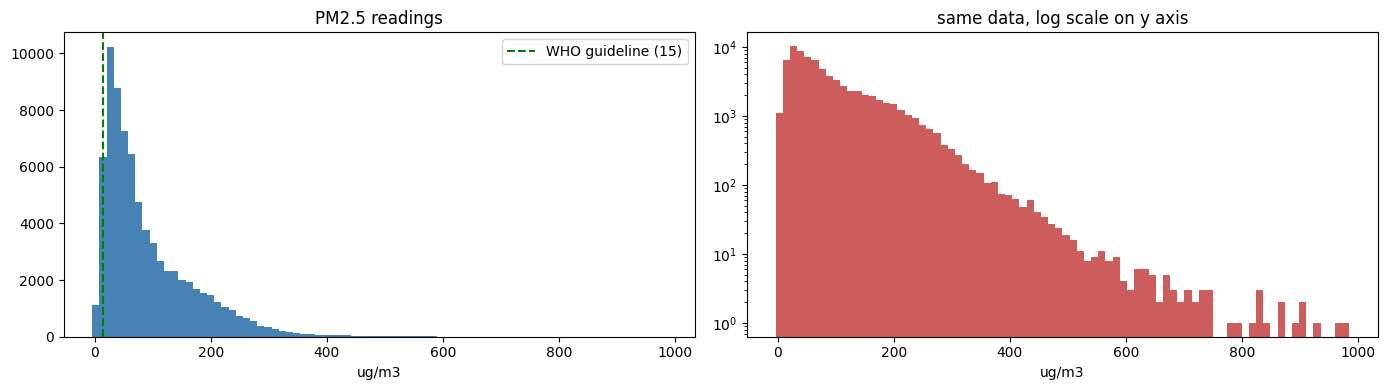

In [20]:
import matplotlib.pyplot as plt

readings = work.select("pm25").toPandas()["pm25"]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(readings, bins=80, color="steelblue")
axes[0].axvline(15, color="green", linestyle="--", label="WHO guideline (15)")
axes[0].set_title("PM2.5 readings")
axes[0].set_xlabel("ug/m3")
axes[0].legend()

# log scale on the y axis, so the rare extreme hours stay visible
axes[1].hist(readings, bins=80, color="indianred")
axes[1].set_yscale("log")
axes[1].set_title("same data, log scale on y axis")
axes[1].set_xlabel("ug/m3")

plt.tight_layout()
plt.show()

### Would a log transform help?

Many models prefer a roughly symmetric target. **Skew** measures lopsidedness:
0 is symmetric, above +1 is strongly stretched to the right.

We compare the raw readings with `log(1 + reading)`.

**Look for:** whether the log version is much closer to 0. If it is, predicting
the log and converting back afterwards becomes a genuine option for Part 3.

In [21]:
import numpy as np

def skew(values):
    values = np.asarray(values, dtype=float)
    centred = values - values.mean()
    return (centred ** 3).mean() / (values.std() ** 3)

# log(1 + x) is undefined at or below -1, and we just found readings as low as
# -4. Nudge the impossible values up to 0 first -- that is the fix we will make
# properly in Part 2 anyway.
positive = readings.clip(lower=0)

print(f"skew of raw readings   : {skew(positive):+.3f}")
print(f"skew of log(1+reading) : {skew(np.log1p(positive)):+.3f}")
print()
print("0 means symmetric. Above +1 means a long tail stretching right.")

skew of raw readings   : +1.863
skew of log(1+reading) : -0.245

0 means symmetric. Above +1 means a long tail stretching right.


## Q6 — Does pollution follow the seasons?

Dhaka has a dry season and a monsoon. Rain washes particles out of the air, so
we would expect a difference. The question is how big.

**Look for:** the ratio between the worst month and the best month.

In [22]:
monthly = (work.groupBy("month")
               .agg(F.avg("pm25").alias("average"),
                    F.count("*").alias("hours"))
               .orderBy("month")
               .toPandas())

NAMES = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
         "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

for _, row in monthly.iterrows():
    name = NAMES[int(row["month"]) - 1]
    print(f"  {name}  {row['average']:>6.1f}  {'#' * int(row['average'] / 4)}")

print()
print(f"worst month is {monthly['average'].max() / monthly['average'].min():.1f}x "
      f"the cleanest month")

  Jan   199.8  #################################################
  Feb   165.5  #########################################
  Mar   117.3  #############################
  Apr    69.7  #################
  May    55.6  #############
  Jun    41.2  ##########
  Jul    31.3  #######
  Aug    36.1  #########
  Sep    40.5  ##########
  Oct    65.0  ################
  Nov   109.1  ###########################
  Dec   163.9  ########################################

worst month is 6.4x the cleanest month


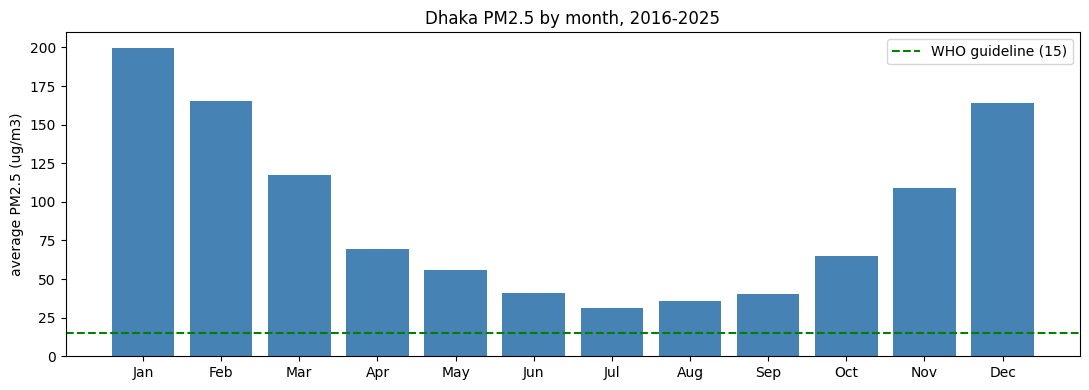

In [23]:
plt.figure(figsize=(11, 4))
plt.bar(NAMES, monthly["average"], color="steelblue")
plt.axhline(15, color="green", linestyle="--", label="WHO guideline (15)")
plt.ylabel("average PM2.5 (ug/m3)")
plt.title("Dhaka PM2.5 by month, 2016-2025")
plt.legend()
plt.tight_layout()
plt.show()

## Q7 — Does pollution follow the time of day?

**Look for:** a dip in the afternoon and a peak late at night. The physical
reason is that afternoon sun heats the ground, air rises and mixes, and the
pollution spreads through a taller column. At night the air settles into a thin
layer near the ground and the same emissions get concentrated.

   0:00   111.7  ###########################
   1:00   111.0  ###########################
   2:00   108.3  ###########################
   3:00   108.0  ##########################
   4:00   103.9  #########################
   5:00   102.1  #########################
   6:00   103.9  #########################
   7:00   107.2  ##########################
   8:00   104.6  ##########################
   9:00    98.9  ########################
  10:00    88.9  ######################
  11:00    78.3  ###################
  12:00    70.1  #################
  13:00    66.4  ################
  14:00    63.5  ###############
  15:00    62.7  ###############
  16:00    62.7  ###############
  17:00    67.5  ################
  18:00    79.3  ###################
  19:00    92.9  #######################
  20:00   102.7  #########################
  21:00   108.0  ###########################
  22:00   110.2  ###########################
  23:00   111.9  ###########################


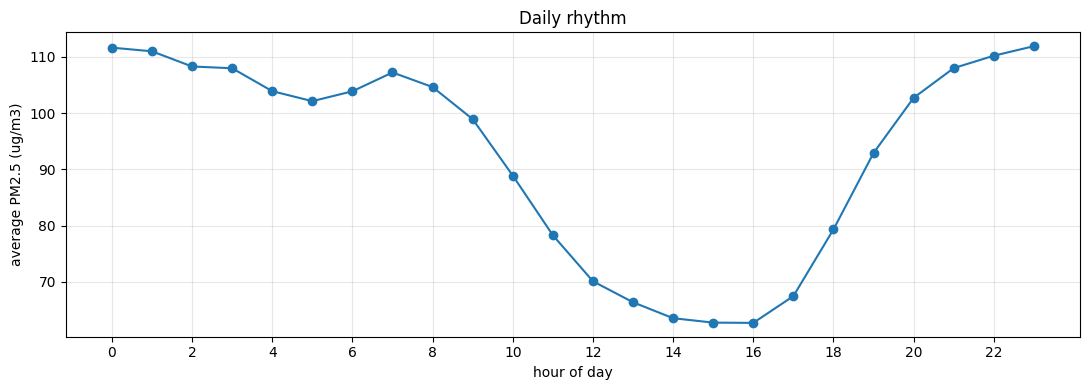

In [24]:
hourly = (work.groupBy("hour")
              .agg(F.avg("pm25").alias("average"))
              .orderBy("hour")
              .toPandas())

for _, row in hourly.iterrows():
    print(f"  {int(row['hour']):>2}:00  {row['average']:>6.1f}  "
          f"{'#' * int(row['average'] / 4)}")

plt.figure(figsize=(11, 4))
plt.plot(hourly["hour"], hourly["average"], marker="o")
plt.xticks(range(0, 24, 2))
plt.xlabel("hour of day")
plt.ylabel("average PM2.5 (ug/m3)")
plt.title("Daily rhythm")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Q8 — Does the day of the week matter?

Traffic is lighter on the weekend, so it might.

**Look for:** whether the bars are actually different, or all about the same
height. A flat result is a useful finding — it means this column would be dead
weight as a model input.

In [25]:
# dayofweek: 1 = Sunday ... 7 = Saturday
weekly = (work.withColumn("dow", F.dayofweek("ts"))
              .groupBy("dow")
              .agg(F.avg("pm25").alias("average"))
              .orderBy("dow")
              .toPandas())

DAYS = ["Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"]

for _, row in weekly.iterrows():
    print(f"  {DAYS[int(row['dow']) - 1]}  {row['average']:>6.1f}  "
          f"{'#' * int(row['average'] / 2)}")

spread = weekly["average"].max() - weekly["average"].min()
print()
print(f"difference between busiest and quietest day: {spread:.1f} ug/m3")
print(f"for comparison, the monthly swing was "
      f"{monthly['average'].max() - monthly['average'].min():.1f} ug/m3")

  Sun    91.8  #############################################
  Mon    92.1  ##############################################
  Tue    94.4  ###############################################
  Wed    95.5  ###############################################
  Thu    94.8  ###############################################
  Fri    91.4  #############################################
  Sat    89.1  ############################################

difference between busiest and quietest day: 6.4 ug/m3
for comparison, the monthly swing was 168.5 ug/m3


## Q9 — Is the air getting better or worse over the years?

**Look for:** the trend, but read it carefully. Check each year's coverage from
Q3 before believing its average. A year that only recorded the dry season will
look terrible for reasons that have nothing to do with pollution getting worse.

In [26]:
yearly = (work.groupBy("year")
              .agg(F.avg("pm25").alias("average"),
                   F.count("*").alias("hours"))
              .orderBy("year")
              .toPandas())

for _, row in yearly.iterrows():
    coverage = row["hours"] / 8760
    flag = "   <-- partial year, do not compare" if coverage < 0.5 else ""
    print(f"  {int(row['year'])}  {row['average']:>6.1f}  "
          f"(coverage {coverage:>4.0%}){flag}")

  2016    67.8  (coverage  84%)
  2017    79.9  (coverage  97%)
  2018   100.1  (coverage  74%)
  2019    86.2  (coverage  98%)
  2020    84.4  (coverage  97%)
  2021    99.1  (coverage  92%)
  2022    95.9  (coverage  96%)
  2023   103.6  (coverage  99%)
  2024    97.4  (coverage 100%)
  2025   171.1  (coverage  23%)   <-- partial year, do not compare


## Q10 — How fast does the air change from one hour to the next?

This sets the difficulty of the whole problem. If pollution barely moves in an
hour, predicting the next hour is easy. If it swings wildly, it is hard.

We compare each reading with the one an hour before. Because of the gaps found
in Q4, we match on **the actual timestamp**, not on the previous row.

**Look for:** the standard deviation, and the share of hours that jump by more
than 50. That share is roughly how often a naive "next hour equals this hour"
guess would fail badly.

In [27]:
now = work.select("ts", F.col("pm25").alias("now"))
one_hour_earlier = work.select(
    (F.col("ts") + F.expr("INTERVAL 1 HOUR")).alias("ts"),
    F.col("pm25").alias("before"))

changes = (now.join(one_hour_earlier, "ts")
              .withColumn("change", F.col("now") - F.col("before"))
              .cache())

changes.select("change").describe().show()

big_jumps = changes.filter(F.abs(F.col("change")) > 50).count()
print(f"hours that moved more than 50 ug/m3: {big_jumps:,} "
      f"({big_jumps / changes.count():.1%})")

+-------+--------------------+
|summary|              change|
+-------+--------------------+
|  count|               74858|
|   mean|0.012663977130032863|
| stddev|  33.169188491504435|
|    min|              -747.0|
|    max|               897.0|
+-------+--------------------+

hours that moved more than 50 ug/m3: 5,308 (7.1%)


## Q11 — How long does the air remember?

**The single most useful chart in this notebook.** It decides which inputs we
build in Part 2.

*Correlation* here means: if I know the reading N hours ago, how well does that
predict the reading now? 1.0 is perfect, 0.0 is useless.

We compute it by shifting the table forward N hours and joining it to itself on
the timestamp.

**Look for two things:**

1. How fast the line falls as N grows.
2. Whether it **rises again** near 24 hours. If it does, that is the daily cycle
   showing up — the same hour yesterday is a genuinely good clue, better than
   twelve hours ago.

In [28]:
LAGS = [1, 2, 3, 6, 12, 18, 24, 48, 72, 168]
results = []

for lag in LAGS:
    shifted = work.select(
        (F.col("ts") + F.expr(f"INTERVAL {lag} HOURS")).alias("ts"),
        F.col("pm25").alias("past"))

    joined = work.select("ts", "pm25").join(shifted, "ts")
    r = joined.corr("pm25", "past")
    results.append((lag, r))

    print(f"  {lag:>4} hours ago   correlation {r:.3f}   {'#' * int(r * 50)}")

     1 hours ago   correlation 0.915   #############################################
     2 hours ago   correlation 0.846   ##########################################
     3 hours ago   correlation 0.789   #######################################
     6 hours ago   correlation 0.650   ################################
    12 hours ago   correlation 0.545   ###########################
    18 hours ago   correlation 0.600   #############################
    24 hours ago   correlation 0.725   ####################################
    48 hours ago   correlation 0.667   #################################
    72 hours ago   correlation 0.638   ###############################
   168 hours ago   correlation 0.591   #############################


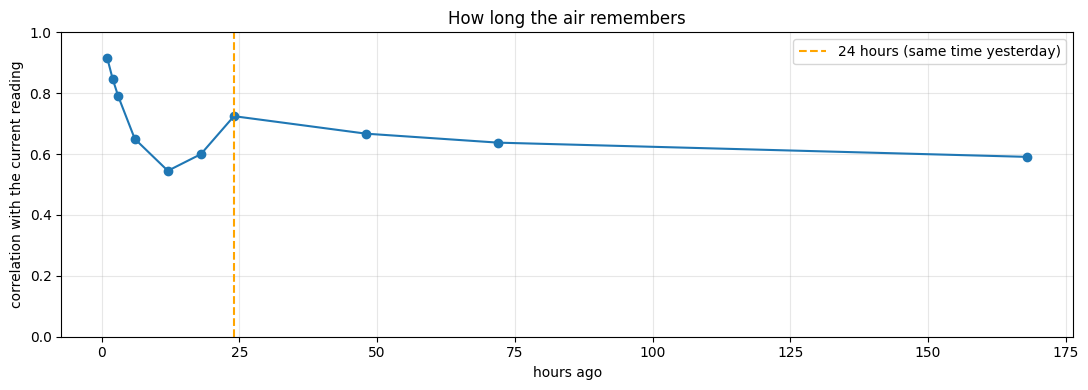

In [29]:
plt.figure(figsize=(11, 4))
plt.plot([lag for lag, _ in results], [r for _, r in results], marker="o")
plt.axvline(24, color="orange", linestyle="--", label="24 hours (same time yesterday)")
plt.xlabel("hours ago")
plt.ylabel("correlation with the current reading")
plt.title("How long the air remembers")
plt.ylim(0, 1)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Q12 — Can we use `nowcast`, `aqi` and `aqi_category` as inputs?

This is the trap that quietly ruins air-quality projects, so it gets its own
section.

`nowcast` is AirNow's smoothed number. It is a weighted average of roughly the
last twelve hours — **including the hour we are trying to predict**. `aqi` and
`aqi_category` are then calculated from `nowcast`.

If we feed the model `nowcast` for the same hour, we are handing it the answer.
The model would score beautifully in testing and be useless in reality, because
in a live system that value does not exist yet.

**Look for:** how close the correlation is to 1.0.

In [30]:
# A handful of rows are flagged Valid but still carry the -999 no-data code in
# nowcast and aqi. Left in, those few rows would drag the correlation down and
# tell us nothing. Worth knowing they exist -- a quality flag is not a guarantee.
hidden = work.filter(F.col("nowcast") == -999.0).count()
print(f"rows flagged Valid but holding -999 in nowcast: {hidden}")
print()

honest = work.filter(F.col("nowcast") != -999.0)

print("correlation with the reading we want to predict:")
print(f"  nowcast, same hour : {honest.corr('pm25', 'nowcast'):.4f}")
print(f"  aqi,     same hour : {honest.corr('pm25', 'aqi'):.4f}")

rows flagged Valid but holding -999 in nowcast: 94

correlation with the reading we want to predict:
  nowcast, same hour : 0.9749
  aqi,     same hour : 0.9372


### A second piece of evidence

If `aqi_category` described the current reading, each category would occupy its
own band of values with no overlap.

**Look for:** the min and max columns. The bands overlap heavily — `Good` hours
and `Unhealthy` hours share the same raw readings. That is because the category
describes the smoothed twelve-hour value, not this hour.

In [31]:
(work.groupBy("aqi_category")
     .agg(F.count("*").alias("hours"),
          F.min("pm25").alias("lowest"),
          F.avg("pm25").alias("average"),
          F.max("pm25").alias("highest"))
     .orderBy("average")
     .show(truncate=False))

+------------------------------+-----+------+------------------+-------+
|aqi_category                  |hours|lowest|average           |highest|
+------------------------------+-----+------+------------------+-------+
|Good                          |1473 |-4.0  |7.806517311608961 |19.0   |
|Moderate                      |16523|-4.0  |24.041033710585246|58.0   |
|Unhealthy for Sensitive Groups|14018|4.0   |44.400128406334716|91.0   |
|N/A                           |96   |-2.0  |75.69791666666667 |483.0  |
|Unhealthy                     |27522|13.0  |91.30640941792021 |272.0  |
|Very Unhealthy                |11882|15.0  |188.32199966335634|436.0  |
|Hazardous                     |3860 |56.0  |310.6847150259067 |985.0  |
+------------------------------+-----+------+------------------+-------+



## Q13 — How often is the air actually dangerous?

The official health scale, in plain counts. This is the number that makes the
project worth doing.

In [32]:
total = work.count()

counts = (work.groupBy("aqi_category")
              .count()
              .orderBy("count", ascending=False)
              .collect())

for row in counts:
    share = row["count"] / total
    print(f"  {row['aqi_category']:<32} {row['count']:>7,}  {share:>6.1%}  "
          f"{'#' * int(share * 100)}")

  Unhealthy                         27,522   36.5%  ####################################
  Moderate                          16,523   21.9%  #####################
  Unhealthy for Sensitive Groups    14,018   18.6%  ##################
  Very Unhealthy                    11,882   15.8%  ###############
  Hazardous                          3,860    5.1%  #####
  Good                               1,473    2.0%  #
  N/A                                   96    0.1%  


## Q14 — What did the worst hours look like?

**Look for:** when they happened. If the extremes cluster in particular months,
that agrees with the seasonal pattern from Q6.

In [33]:
(work.select("ts", "pm25", "aqi_category")
     .orderBy(F.col("pm25").desc())
     .show(10, truncate=False))

+-------------------+-----+------------+
|ts                 |pm25 |aqi_category|
+-------------------+-----+------------+
|2019-01-20 15:00:00|985.0|Hazardous   |
|2024-02-18 09:00:00|970.0|Hazardous   |
|2021-03-16 03:00:00|927.0|Hazardous   |
|2019-02-10 13:00:00|910.0|Hazardous   |
|2023-03-17 13:00:00|903.0|Hazardous   |
|2021-03-16 04:00:00|888.0|Hazardous   |
|2019-02-03 10:00:00|873.0|Hazardous   |
|2021-02-24 09:00:00|867.0|Hazardous   |
|2018-02-07 07:00:00|838.0|Hazardous   |
|2019-01-24 20:00:00|833.0|Hazardous   |
+-------------------+-----+------------+
only showing top 10 rows


## Q15 — See it with your own eyes

Statistics summarise. A plot shows the texture: the daily rhythm, the multi-day
episodes, and how sharply spikes arrive.

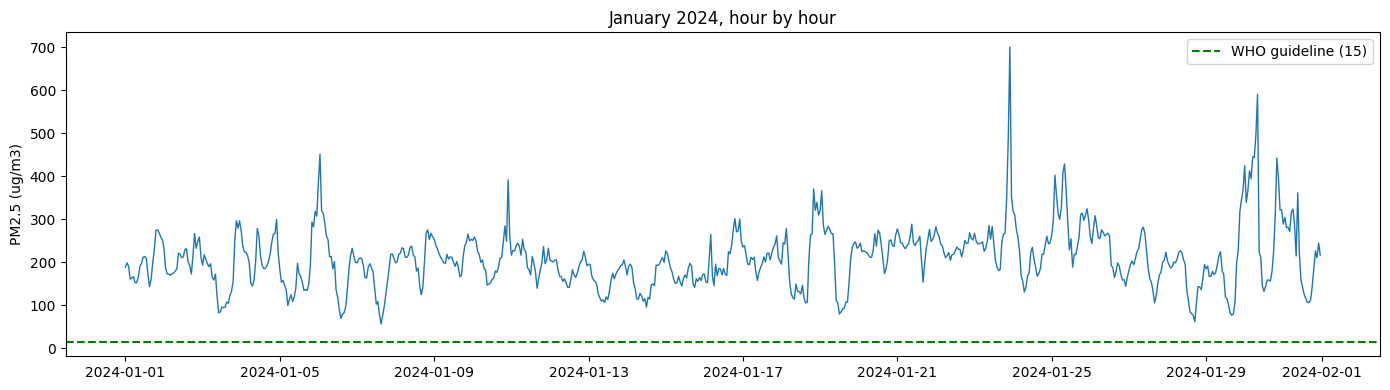

In [34]:
one_month = (work
             .filter((F.col("ts") >= "2024-01-01") & (F.col("ts") < "2024-02-01"))
             .orderBy("ts")
             .select("ts", "pm25")
             .toPandas())

plt.figure(figsize=(14, 4))
plt.plot(one_month["ts"], one_month["pm25"], linewidth=1)
plt.axhline(15, color="green", linestyle="--", label="WHO guideline (15)")
plt.ylabel("PM2.5 (ug/m3)")
plt.title("January 2024, hour by hour")
plt.legend()
plt.tight_layout()
plt.show()

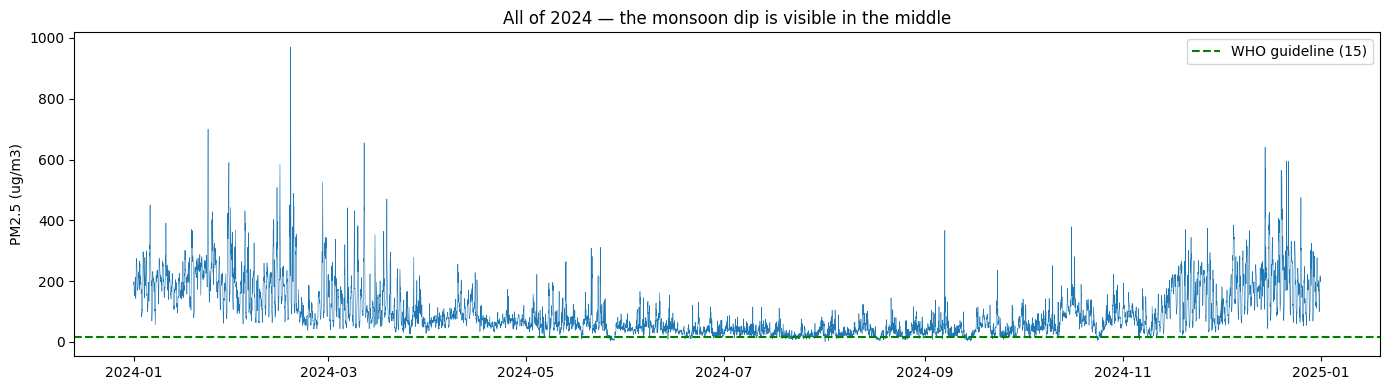

In [35]:
one_year = (work
            .filter(F.col("year") == 2024)
            .orderBy("ts")
            .select("ts", "pm25")
            .toPandas())

plt.figure(figsize=(14, 4))
plt.plot(one_year["ts"], one_year["pm25"], linewidth=0.4)
plt.axhline(15, color="green", linestyle="--", label="WHO guideline (15)")
plt.ylabel("PM2.5 (ug/m3)")
plt.title("All of 2024 — the monsoon dip is visible in the middle")
plt.legend()
plt.tight_layout()
plt.show()

---
# What we found

Fill in the numbers from your own run — they should match these.

| # | Question | Finding |
|---|---|---|
| Q1 | Useful columns? | `site`, `parameter`, `unit`, `duration` never change. Dead weight. |
| Q2 | Quality flag? | ~2,300 rows are not `Valid` and hold `-999`. Must go. |
| Q2b | Duplicate hours? | 6 hours appear twice, from the seams between yearly files. |
| Q5b | Impossible values? | 24 readings are negative, as low as -4.0. |
| Q3 | Coverage? | 2016-03 to 2025-03. Some years near 100%, one near 74%, the last only ~23%. |
| Q4 | Missing hours? | ~5% missing, in ~517 separate gaps. Most are 1 hour; the worst is ~76 days. |
| Q5 | Distribution? | Median ~65, mean ~93, max 985. Strongly right-skewed; `log` almost fixes it. |
| Q6 | Season? | January averages ~200, July ~31. A **6x** swing. The strongest pattern in the data. |
| Q7 | Time of day? | Peaks around midnight (~112), dips mid-afternoon (~63). |
| Q8 | Day of week? | Essentially flat — under 7 ug/m3 across all days. Weak signal. |
| Q9 | Yearly trend? | Drifts upward, but the last year is partial and dry-season-only. |
| Q10 | Hourly volatility? | Standard deviation ~33. About 7% of hours move more than 50. |
| Q11 | Memory? | 0.92 at 1 hour, falls to ~0.55 by 12 hours, **rises back to ~0.72 at 24 hours**. |
| Q12 | `nowcast` / `aqi`? | Correlate 0.97 / 0.84 with the target *for the same hour*. Contain the answer. |
| Q13 | Health? | Only ~2% of hours are `Good`. A third are `Unhealthy` or worse. |

# Decisions this opens up — for Part 2

**1. The constant columns.** Q1 settles it: drop them.

**2. The `-999` rows.** Q2 settles it: drop them. But note this leaves holes in
time, which feeds into the next decision.

**2b. Duplicate hours and negative readings.** Both were found above. The 6
duplicates have to go before anything is sorted by time. The 24 negatives can
be nudged up to 0 or dropped — nudging keeps the hour in the series, dropping
punches another hole in it.

**3. The missing hours.** Q4 says ~5%, mostly single hours. Options: build a
complete hourly timeline so that "one row back" always means "one hour back";
or fill the small gaps and cut around the large ones. The 76-day gap has to be
handled either way.

**4. `nowcast`, `aqi`, `aqi_category`.** Q12 says using them for the current
hour is cheating. Options: drop them entirely, or use only their **past** values.
Their high correlation makes the past values potentially useful.

**5. Which lags to build.** Q11 is the evidence. 1, 2 and 3 hours ago are
strong. 24 hours ago beats 12 hours ago, so the daily cycle is real and worth a
feature. Whether 168 hours (one week) earns its place is an open question — it
costs rows, because early hours have no week-old value to look back at.

**6. Calendar inputs.** Q6 makes month clearly worth including and Q7 makes hour
worth including. Q8 suggests day of week is not.

**7. Transform the target?** Q5 shows `log(1 + reading)` is far more symmetric.
Options: predict the raw value, or predict the log and convert back. Worth
testing both.

**8. Where to split train and test.** It must be by **time**, never randomly —
shuffling would let the model train on the future and be tested on the past.
The open question is the cut-off date, and Q3 and Q9 say to be careful: the
final partial year is dry-season-only, so a test set made of it alone is
seasonally biased.

**9. Which model.** With one station and one measurement, the useful inputs are
past readings and calendar position. Gradient-boosted trees suit that: they
handle skew and interactions without scaling, and they report which input
mattered. A linear model makes a good sanity check.

**10. Do we need PCA?** Reasonable to ask, and the honest answer here is
probably no.

PCA compresses many correlated columns into a few. We have the opposite
situation: after dropping the constants and the leaky columns, we are down to
about three real inputs plus whatever lags we build.

It becomes a fairer question *after* Part 2, because lag features are heavily
correlated with each other — Q11 shows exactly that. Even then there are two
arguments against it. Tree models are not troubled by correlated inputs, so
there is little to gain. And PCA mixes the columns into unnamed combinations,
which destroys the ability to say *"the reading 24 hours ago mattered most"* —
one of the more reportable results this project can produce.

Worth revisiting only if we add many more inputs, for example weather data or
several monitoring stations.

# Next

**Part 2 — Prepare the data.** Act on decisions 1 through 6, and build the
inputs the model will learn from.

---
---

# Part 2: Prepare the data

Part 1 only looked. This part acts on what it found, and builds the inputs the
model will actually learn from.

Every decision below points back at the evidence for it.

| Decision | Evidence | Call |
|---|---|---|
| Drop the four constant columns | Q1 — they never vary | Drop |
| Drop the `-999` rows | Q2 — 2,342 of them, not real readings | Drop |
| Collapse duplicate hours | 6 hours appear twice, with **different values** | Average them |
| Fix negative readings | 24 readings below zero, lowest −4.0 | Nudge up to 0 |
| Handle missing hours | Q4 — 5.1% missing, 517 gaps | Build a complete hourly timeline |
| Which lags | Q11 — 0.92 at 1h, and 24h beats 12h | 1, 2, 3, 24 |
| `nowcast` / `aqi` | Q12 — 0.97 / 0.94 with the same hour | Drop them; keep only *past* `nowcast` |
| Calendar inputs | Q6 season, Q7 time of day, Q8 flat weekdays | Keep month and hour, drop weekday |
| Coverage of rolling windows | Uneven between periods | Require 20 of the last 24 hours |
| Which class label to predict | Measured below — the published one is nearly free | Build our own from the reading |
| Train/test split | Never random on a time series | By time, into **three** parts |

Still open, and settled in Part 3 rather than here: whether to predict the raw
reading or its logarithm, and which model.

**Two targets come out of this part**, not one:

- `pm25` — the reading itself, a number. Scored with RMSE.
- `category` — the health label for that reading. Scored with per-class F1.

Step 17 explains why we build the label ourselves instead of using the one that
came with the file.

## Step 9 — Collapse the duplicate hours

The six repeated hours hold **different readings**, so we cannot just keep
whichever row Spark happens to hand us first — that would give a different
answer on different runs, and Step 3 exists precisely to prevent that.

Look at the dates: 2016-03-13, 2017-03-12, 2018-03-11, 2019-03-10. Each is the
**second Sunday in March** — the day clocks go forward in the United States. The
export tool appears to run on US time, so the 03:00 hour gets written twice.

We average the two readings. It is deterministic, it is defensible, and it
touches six rows out of seventy-five thousand.

We also select down to the columns we are keeping. `aqi` and `aqi_category` stay
for now — not as model inputs, but because `aqi_category` is the secondary
target we may predict later.

In [36]:
# Q12 found 94 rows flagged Valid that still hold -999 in nowcast. Left alone,
# that sentinel would ride into nowcast_lag_1 and poison the feature. Null it
# first, so the average below ignores it rather than averaging it in.
cleaned = work.withColumn(
    "nowcast",
    F.when(F.col("nowcast") == -999.0, None).otherwise(F.col("nowcast")))

prepared = (cleaned
            .groupBy("ts")
            .agg(F.round(F.avg("pm25"), 1).alias("pm25"),
                 F.round(F.avg("nowcast"), 1).alias("nowcast"),
                 F.round(F.avg("aqi")).cast("int").alias("aqi"),
                 # deterministic tie-break; affects only the 6 duplicate hours
                 F.max("aqi_category").alias("aqi_category")))

print("rows before:", f"{work.count():,}")
print("rows after :", f"{prepared.count():,}")
print("collapsed  :", work.count() - prepared.count())
print("nowcast sentinels nulled:",
      work.filter(F.col("nowcast") == -999.0).count())

rows before: 75,374
rows after : 75,368
collapsed  : 6
nowcast sentinels nulled: 94


## Step 10 — Nudge the impossible readings up to zero

`greatest(pm25, 0.0)` returns whichever is larger, so a negative becomes 0 and
everything else passes through untouched.

We nudge rather than delete. Deleting would punch another hole in the hourly
sequence, and Step 12 is all about not having holes.

In [37]:
print("lowest reading before:", prepared.agg(F.min("pm25")).first()[0])

prepared = prepared.withColumn("pm25", F.greatest(F.col("pm25"), F.lit(0.0)))

print("lowest reading after :", prepared.agg(F.min("pm25")).first()[0])

lowest reading before: -4.0
lowest reading after : 0.0


## Step 11 — Build a complete hourly timeline

**The most important step in this notebook.** Everything downstream depends on
getting it right.

Here is the problem. To build "the reading one hour ago", Spark offers `lag()`,
which looks **one row back**. Q4 found 5.1% of hours missing. So after a gap,
one row back is not one hour back — it might be 76 days back, and the model
would learn from it without complaint.

The fix is to stop relying on rows lining up with hours, and guarantee it
instead:

1. Generate **every** hour between the first and last reading — 79,457 of them.
2. Attach the readings we have to that list.
3. Hours with no reading become explicitly empty rather than silently absent.

Now row N really is exactly N hours after row 0, everywhere, and `lag()` means
what it says.

In [38]:
first_ts, last_ts = prepared.agg(F.min("ts"), F.max("ts")).first()

# sequence() generates every hour from first to last, one row each
timeline = (spark
            .createDataFrame([(first_ts, last_ts)], "start timestamp, end timestamp")
            .select(F.explode(
                F.sequence("start", "end", F.expr("INTERVAL 1 HOUR"))).alias("ts")))

# A left join keeps every hour on the timeline; hours with no reading get nulls
hourly = timeline.join(prepared, on="ts", how="left").cache()

print("hours on the timeline:", f"{hourly.count():,}")
print("hours with a reading :", f"{hourly.filter(F.col('pm25').isNotNull()).count():,}")
print("hours left empty     :", f"{hourly.filter(F.col('pm25').isNull()).count():,}")

hours on the timeline: 79,457
hours with a reading : 75,368
hours left empty     : 4,089


### Check it worked

If the timeline is truly complete, then the number of hours between the first
and last row equals the number of rows minus one, exactly.

**Look for:** the word `True`. If it says `False`, nothing below this point can
be trusted.

In [39]:
rows_on_timeline = hourly.count()
hours_spanned = int((last_ts - first_ts).total_seconds() / 3600) + 1

print("rows on timeline :", f"{rows_on_timeline:,}")
print("hours spanned    :", f"{hours_spanned:,}")
print("one row per hour :", rows_on_timeline == hours_spanned)
print()

# and no hour appears twice
print("no duplicate hours:",
      hourly.select("ts").distinct().count() == rows_on_timeline)

rows on timeline : 79,457
hours spanned    : 79,457
one row per hour : True

no duplicate hours: True


## Step 12 — Build the lag features

A **lag** is simply a past value used as an input. `lag_1` is the reading one
hour ago, `lag_24` the reading at this time yesterday.

Q11 chose these for us: correlation is 0.92 one hour back, and 24 hours back
(0.72) beats 12 hours back (0.55) because of the daily cycle.

`Window.orderBy("ts")` tells Spark to sort by time and step backwards through
the rows. This is only safe because Step 11 made rows and hours the same thing.

`lag_168` — the same hour last week — is built too, so we can measure what it
costs before deciding whether to keep it.

In [40]:
from pyspark.sql.window import Window

in_time_order = Window.orderBy("ts")

featured = hourly
for hours_back in [1, 2, 3, 24, 168]:
    featured = featured.withColumn(
        f"lag_{hours_back}", F.lag("pm25", hours_back).over(in_time_order))

# The past value of nowcast is safe to use -- it is only the CURRENT hour's
# nowcast that contains the answer (Q12).
featured = featured.withColumn("nowcast_lag_1", F.lag("nowcast", 1).over(in_time_order))

featured.select("ts", "pm25", "lag_1", "lag_2", "lag_24").show(5)

+-------------------+-----+-----+-----+------+
|                 ts| pm25|lag_1|lag_2|lag_24|
+-------------------+-----+-----+-----+------+
|2016-03-01 02:00:00|196.0| NULL| NULL|  NULL|
|2016-03-01 03:00:00|289.0|196.0| NULL|  NULL|
|2016-03-01 04:00:00|240.0|289.0|196.0|  NULL|
|2016-03-01 05:00:00|290.0|240.0|289.0|  NULL|
|2016-03-01 06:00:00|245.0|290.0|240.0|  NULL|
+-------------------+-----+-----+-----+------+
only showing top 5 rows


## Step 13 — Build the rolling features

A single past reading can be a fluke. An **average over several past hours** is
steadier, and the **spread** over those hours says whether the air is calm or
swinging about — Q10 showed 7% of hours move by more than 50.

The critical detail is `rowsBetween(-3, -1)`.

- `-3` to `-1` means the three hours **before** now.
- `-2` to `0` would include the current hour — the very value we are predicting.

That single character is the difference between a real forecast and a model that
scores beautifully and is useless in production.

`roll_hours_24` counts how many of the last 24 hours actually had a reading. On
the timeline built in Step 11, some are empty, and Spark averages whatever is
there — so an average can rest on 3 hours or on 24.

We use this column as a **gate, not an input** (Step 16). It describes the
monitoring station, not the air, so it does not belong among the features.

In [41]:
last_3_hours = in_time_order.rowsBetween(-3, -1)     # ends at -1, never 0
last_24_hours = in_time_order.rowsBetween(-24, -1)

featured = (featured
            .withColumn("roll_mean_3", F.round(F.avg("pm25").over(last_3_hours), 2))
            .withColumn("roll_mean_24", F.round(F.avg("pm25").over(last_24_hours), 2))
            .withColumn("roll_std_24", F.round(F.stddev("pm25").over(last_24_hours), 2))
            .withColumn("roll_hours_24", F.count("pm25").over(last_24_hours)))

featured.select("ts", "pm25", "roll_mean_3", "roll_mean_24",
                "roll_std_24", "roll_hours_24").show(5)

+-------------------+-----+-----------+------------+-----------+-------------+
|                 ts| pm25|roll_mean_3|roll_mean_24|roll_std_24|roll_hours_24|
+-------------------+-----+-----------+------------+-----------+-------------+
|2016-03-01 02:00:00|196.0|       NULL|        NULL|       NULL|            0|
|2016-03-01 03:00:00|289.0|      196.0|       196.0|       NULL|            1|
|2016-03-01 04:00:00|240.0|      242.5|       242.5|      65.76|            2|
|2016-03-01 05:00:00|290.0|     241.67|      241.67|      46.52|            3|
|2016-03-01 06:00:00|245.0|      273.0|      253.75|      45.02|            4|
+-------------------+-----+-----------+------------+-----------+-------------+
only showing top 5 rows


## Step 14 — Build the calendar features

Q6 found a 6.4x swing between January and July. Q7 found a clear daily rhythm.
Both belong in the model. Q8 found nothing in the day of week, so it stays out.

**Why the sine and cosine columns?** Hour 23 and hour 0 are one hour apart, but
as plain numbers they look 23 apart. Mapping the hour onto a circle fixes that:
sine and cosine together place each hour on a ring, so midnight sits right next
to 23:00 where it belongs. Same idea for December and January.

We keep the plain `hour` and `month` too. Tree models split on thresholds and
often prefer the raw number; the circular pair helps other model types. Costing
nothing to keep both, we let Part 3 decide by feature importance.

In [42]:
import math

TWO_PI = 2 * math.pi

featured = (featured
            .withColumn("hour", F.hour("ts"))
            .withColumn("month", F.month("ts"))
            .withColumn("hour_sin", F.round(F.sin(F.hour("ts") * (TWO_PI / 24)), 4))
            .withColumn("hour_cos", F.round(F.cos(F.hour("ts") * (TWO_PI / 24)), 4))
            .withColumn("month_sin", F.round(F.sin((F.month("ts") - 1) * (TWO_PI / 12)), 4))
            .withColumn("month_cos", F.round(F.cos((F.month("ts") - 1) * (TWO_PI / 12)), 4)))

featured.select("ts", "hour", "hour_sin", "hour_cos",
                "month", "month_sin", "month_cos").show(5)

+-------------------+----+--------+--------+-----+---------+---------+
|                 ts|hour|hour_sin|hour_cos|month|month_sin|month_cos|
+-------------------+----+--------+--------+-----+---------+---------+
|2016-03-01 02:00:00|   2|     0.5|   0.866|    3|    0.866|      0.5|
|2016-03-01 03:00:00|   3|  0.7071|  0.7071|    3|    0.866|      0.5|
|2016-03-01 04:00:00|   4|   0.866|     0.5|    3|    0.866|      0.5|
|2016-03-01 05:00:00|   5|  0.9659|  0.2588|    3|    0.866|      0.5|
|2016-03-01 06:00:00|   6|     1.0|     0.0|    3|    0.866|      0.5|
+-------------------+----+--------+--------+-----+---------+---------+
only showing top 5 rows


## Step 15 — What does each feature cost in rows?

A row is only usable if the value we want to predict **and** every input are
present. An hour sitting just after a long gap has no `lag_24`, so it has to go.

Longer lags reach further back and therefore lose more rows. Before committing
to `lag_168`, measure what it takes.

**Look for:** the jump when `lag_168` is added. If it costs a lot of rows for a
feature Q11 rated only 0.59, it is not worth it.

In [43]:
CORE = ["lag_1", "lag_2", "lag_3", "lag_24",
        "roll_mean_3", "roll_mean_24", "roll_std_24", "nowcast_lag_1"]

with_reading = featured.filter(F.col("pm25").isNotNull())
starting_rows = with_reading.count()

print(f"{'feature set':<34}{'rows kept':>12}{'share':>9}")
print("-" * 55)
print(f"{'hours with a reading':<34}{starting_rows:>12,}{1.0:>9.1%}")

running = []
for feature in CORE + ["lag_168"]:
    running.append(feature)
    kept = with_reading.dropna(subset=running).count()
    print(f"{'+ ' + feature:<34}{kept:>12,}{kept / starting_rows:>9.1%}")

feature set                          rows kept    share
-------------------------------------------------------
hours with a reading                    75,368   100.0%
+ lag_1                                 74,850    99.3%
+ lag_2                                 74,378    98.7%
+ lag_3                                 73,920    98.1%
+ lag_24                                73,099    97.0%
+ roll_mean_3                           73,099    97.0%
+ roll_mean_24                          73,099    97.0%
+ roll_std_24                           73,099    97.0%
+ nowcast_lag_1                         73,099    97.0%
+ lag_168                               71,253    94.5%


### The decision

Two things stand out.

The rolling features cost **nothing**. They average whatever hours are available
rather than demanding a full window, so a partly-empty window still produces a
number.

`lag_168` costs 2.5% of rows — much less than a week-long reach suggested. Q11
rated it 0.59, the weakest of the lags but still above the 12-hour lag. So this
is a judgement call, not an obvious cut. We start without it, and Part 3 can add
it back and measure whether the score actually improves. Cleaner than guessing.

## Step 16 — Insist on a solid 24 hours behind every row

Because the rolling averages are forgiving, some rows carry a `roll_mean_24`
built from only three hours. That number sits in the same column as one built
from a full day, and means something quite different.

Worse, the column that records the difference — `roll_hours_24` — is **not the
same in each period**:

| | full 24 hours | 20–23 hours | fewer than 20 |
|---|---|---|---|
| Training years | 88.7% | 10.7% | 0.6% |
| Test years | 97.0% | 3.0% | 0.04% |

So it describes how often the monitoring station was down, which is a fact about
equipment, not about air. A live system would report 24 almost always.

Two changes, one line each:

1. Keep only rows with at least **20 of the last 24 hours** present.
2. Then drop the column. Once every row is nearly complete it has nothing left
   to say.

The cell below reports the cost against every hour that has a reading, which is
the honest denominator. Most of the rows it removes would have been dropped a
step later anyway, for missing a lag — the gate's real cost, measured on the
finished table in Step 18, is about 0.5%.

In [44]:
before = featured.filter(F.col("pm25").isNotNull()).count()

featured = featured.filter(F.col("roll_hours_24") >= 20)

after = featured.filter(F.col("pm25").isNotNull()).count()
print(f"rows with a reading before: {before:,}")
print(f"rows with a reading after : {after:,}")
print(f"dropped                   : {before - after:,}  ({1 - after / before:.2%})")

rows with a reading before: 75,368
rows with a reading after : 74,297
dropped                   : 1,071  (1.42%)


## Step 17 — Choose the classification target

The project promises two predictions: the **number**, and the **health label**
(`Good`, `Moderate`, … `Hazardous`).

The file already contains a label, `aqi_category`. It is tempting to use it. We
should not, and it is worth measuring why.

Q12 showed that `aqi_category` is not the label for *this hour's reading* — it
is the label for **NowCast**, a smoothed average of roughly the last twelve
hours. Smoothed things barely move, so that label barely moves, so predicting it
is nearly free. A model would score high and have learned almost nothing.

The alternative is to build the label ourselves, by applying the official EPA
thresholds to the reading we actually predict.

The cell below measures both, using the dumbest possible forecast — *"the label
will be whatever it was an hour ago"*. The higher that score, the less room a
real model has to prove anything.

In [45]:
def epa_category(reading):
    """Official EPA health category for a PM2.5 reading in ug/m3."""
    return (F.when(reading <= 12.0, "Good")
             .when(reading <= 35.4, "Moderate")
             .when(reading <= 55.4, "Unhealthy for Sensitive Groups")
             .when(reading <= 150.4, "Unhealthy")
             .when(reading <= 250.4, "Very Unhealthy")
             .otherwise("Hazardous"))


# Measured on `hourly`, the COMPLETE timeline from Step 11 -- not on `featured`,
# which Step 16 has filtered. lag() only means "one hour back" on a frame where
# every hour is still present.
persistence = (hourly
               .withColumn("reading_before", F.lag("pm25", 1).over(in_time_order))
               .withColumn("label_before", F.lag("aqi_category", 1).over(in_time_order))
               .filter(F.col("pm25").isNotNull() &
                       F.col("reading_before").isNotNull() &
                       F.col("aqi_category").isNotNull() &
                       F.col("label_before").isNotNull()))

scores = persistence.select(
    F.avg((F.col("aqi_category") == F.col("label_before")).cast("double")).alias("from_file"),
    F.avg((epa_category(F.col("pm25")) ==
           epa_category(F.col("reading_before"))).cast("double")).alias("our_own"),
).first()

print("Just copying last hour's label is already right...")
print(f"   {scores['from_file']:.1%}  of the time, for the label in the file")
print(f"   {scores['our_own']:.1%}  of the time, for a label built from the reading")
print()
print("The first leaves a real model almost nothing to prove. We use the second.")

Just copying last hour's label is already right...
   83.4%  of the time, for the label in the file
   71.9%  of the time, for a label built from the reading

The first leaves a real model almost nothing to prove. We use the second.


### Add it to the table

`when(...).when(...)` is Spark's version of a chain of if-statements, and the
cut-offs above are the official EPA thresholds for PM2.5.

Writing it as a function means Part 3 can apply the very same thresholds to the
model's predictions, with no risk of two definitions drifting apart.

In [46]:
featured = featured.withColumn("category", epa_category(F.col("pm25")))

featured.select("ts", "pm25", "category", "aqi_category").show(5, truncate=False)

+-------------------+-----+--------------+--------------+
|ts                 |pm25 |category      |aqi_category  |
+-------------------+-----+--------------+--------------+
|2016-03-01 22:00:00|256.0|Hazardous     |Very Unhealthy|
|2016-03-01 23:00:00|257.0|Hazardous     |Very Unhealthy|
|2016-03-02 00:00:00|251.0|Hazardous     |Very Unhealthy|
|2016-03-02 01:00:00|250.0|Very Unhealthy|Very Unhealthy|
|2016-03-02 02:00:00|237.0|Very Unhealthy|Very Unhealthy|
+-------------------+-----+--------------+--------------+
only showing top 5 rows


### How common is each label?

**Look for:** how few hours are `Good`. Plain accuracy would be a terrible score
here — a model that never once predicts `Good` still looks fine on it. Part 3
reports per-class F1 instead.

In [47]:
labelled = featured.filter(F.col("pm25").isNotNull())
total = labelled.count()

for row in (labelled.groupBy("category").count()
                    .orderBy("count", ascending=False).collect()):
    share = row["count"] / total
    print(f"  {row['category']:<32}{row['count']:>7,}{share:>8.1%}  {'#' * int(share * 100)}")

  Unhealthy                        27,348   36.8%  ####################################
  Moderate                         16,443   22.1%  ######################
  Unhealthy for Sensitive Groups   13,060   17.6%  #################
  Very Unhealthy                   11,183   15.1%  ###############
  Hazardous                         3,748    5.0%  #####
  Good                              2,515    3.4%  ###


## Step 18 — The finished table

`roll_hours_24` is gone — it was a gate, not an input. The published
`aqi_category` is gone too, replaced by the `category` we built in Step 17.

Fourteen inputs, two targets, one row per usable hour.

In [48]:
FEATURES = [
    # past readings, chosen by Q11
    "lag_1", "lag_2", "lag_3", "lag_24",
    # summaries of the recent past
    "roll_mean_3", "roll_mean_24", "roll_std_24",
    # the only safe use of nowcast (Q12)
    "nowcast_lag_1",
    # calendar, chosen by Q6 and Q7
    "hour", "month", "hour_sin", "hour_cos", "month_sin", "month_cos",
]
TARGET_NUMBER = "pm25"
TARGET_LABEL = "category"

model_data = (featured
              .select(["ts", TARGET_NUMBER, TARGET_LABEL] + FEATURES)
              .dropna()
              .cache())

print(f"inputs  : {len(FEATURES)}")
print(f"targets : {TARGET_NUMBER} (number), {TARGET_LABEL} (label)")
print(f"rows    : {model_data.count():,}")
model_data.select("ts", "pm25", "category", "lag_1", "lag_24", "roll_mean_24").show(5)

inputs  : 14
targets : pm25 (number), category (label)
rows    : 72,722
+-------------------+-----+--------------+-----+------+------------+
|                 ts| pm25|      category|lag_1|lag_24|roll_mean_24|
+-------------------+-----+--------------+-----+------+------------+
|2016-03-02 02:00:00|237.0|Very Unhealthy|250.0| 196.0|       194.0|
|2016-03-02 03:00:00|272.0|     Hazardous|237.0| 289.0|      195.71|
|2016-03-02 04:00:00|327.0|     Hazardous|272.0| 240.0|       195.0|
|2016-03-02 05:00:00|310.0|     Hazardous|327.0| 290.0|      198.63|
|2016-03-02 06:00:00|299.0|     Hazardous|310.0| 245.0|      199.46|
+-------------------+-----+--------------+-----+------+------------+
only showing top 5 rows


## Step 19 — How much do the features repeat each other?

This is where the PCA question from Part 1 gets a real answer.

PCA squeezes many overlapping columns into a few. So the question is: how much
overlap is there?

**Look for:** the values near 1.0. `lag_1` and `roll_mean_3` will be highly
correlated — of course they are, one is inside the other. That overlap is what
PCA would compress.

This runs 49 separate correlations, so give it a few seconds.

In [49]:
CHECK = ["lag_1", "lag_2", "lag_3", "lag_24",
         "roll_mean_3", "roll_mean_24", "nowcast_lag_1"]

print("       " + "".join(f"{name[:9]:>11}" for name in CHECK))
for row_name in CHECK:
    line = f"{row_name[:6]:<7}"
    for col_name in CHECK:
        line += f"{model_data.corr(row_name, col_name):>11.2f}"
    print(line)

             lag_1      lag_2      lag_3     lag_24  roll_mean  roll_mean  nowcast_l
lag_1         1.00       0.92       0.85       0.72       0.96       0.80       0.98
lag_2         0.92       1.00       0.92       0.71       0.98       0.81       0.97
lag_3         0.85       0.92       1.00       0.68       0.96       0.82       0.93
lag_24        0.72       0.71       0.68       1.00       0.73       0.80       0.74
roll_m        0.96       0.98       0.96       0.73       1.00       0.84       0.99
roll_m        0.80       0.81       0.82       0.80       0.84       1.00       0.85
nowcas        0.98       0.97       0.93       0.74       0.99       0.85       1.00


### So do we use PCA? No.

Two reasons, and the second is the one that matters.

**Trees do not care.** Part 3 uses gradient-boosted trees. Correlated inputs do
not destabilise them the way they destabilise a linear model — a tree picks
whichever column splits best and ignores the twin.

**PCA would cost us the finding.** It replaces named columns with unnamed
combinations. We could no longer say *"the reading 24 hours ago mattered most"*,
which is exactly the kind of result this project should be reporting. Trading a
headline result for a speed-up we do not need on 14 columns is a bad trade.

Worth revisiting only if weather data or several monitoring stations get added,
which would push the column count up by an order of magnitude.

## Step 20 — Split into three, by time

**Never use `randomSplit` on a time series.** It shuffles the rows, so the model
would train on hours from 2025 and be tested on hours from 2017 — learning from
the future to predict the past. Every score would look excellent and none of it
would mean anything.

**Why three parts and not two?** Because in Part 3 we make choices: raw target
or logarithm, `lag_168` in or out, deeper trees or shallower. If we pick the
winner by its score on the test set, the test set has quietly become part of the
training process. It is like sitting the final exam ten times and reporting your
best attempt.

So:

| Part | Period | Used for |
|---|---|---|
| **train** | up to 2022 | the model learns from this |
| **validation** | 2023 | every choice is made here |
| **test** | 2024 onward | opened **once**, at the very end |

The number that goes in the report comes from data no decision ever touched.

In [50]:
TRAIN_END = "2023-01-01"     # train is everything before this
VALID_END = "2024-01-01"     # validation runs from TRAIN_END to here

train = model_data.filter(F.col("ts") < TRAIN_END).cache()
valid = model_data.filter((F.col("ts") >= TRAIN_END) &
                          (F.col("ts") < VALID_END)).cache()
test = model_data.filter(F.col("ts") >= VALID_END).cache()

total = model_data.count()


def period(df):
    row = df.select(F.date_format(F.min("ts"), "yyyy-MM-dd HH:mm").alias("a"),
                    F.date_format(F.max("ts"), "yyyy-MM-dd HH:mm").alias("b")).first()
    return f"{row['a']} to {row['b']}"


for name, part in [("train", train), ("valid", valid), ("test", test)]:
    n = part.count()
    print(f"{name:<6}{n:>8,} rows  {n / total:>5.0%}   {period(part)}")

train   53,445 rows    73%   2016-03-02 02:00 to 2022-12-31 23:00
valid    8,622 rows    12%   2023-01-01 00:00 to 2023-12-31 23:00
test    10,655 rows    15%   2024-01-01 00:00 to 2025-03-24 18:00


### Are the three parts fair?

Two things can quietly ruin a time split.

**Overlap.** If one hour appeared in two parts the whole exercise is void. All
three counts must be zero.

**Season.** Q6 found a 6.4x swing between months. The test period is all of 2024
plus January to March 2025 — and those three extra months are the dirtiest of
the year. So the test set leans toward polluted hours.

That is not a bug, but it must be said out loud: the test average sits above the
training average because of the calendar, not because of the model.

In [51]:
print("overlapping hours (all must be 0)")
print("  train & valid:", train.select("ts").intersect(valid.select("ts")).count())
print("  valid & test :", valid.select("ts").intersect(test.select("ts")).count())
print("  train & test :", train.select("ts").intersect(test.select("ts")).count())
print()

print("average reading in each part")
for name, part in [("train", train), ("valid", valid), ("test", test)]:
    print(f"  {name:<6}{part.agg(F.avg('pm25')).first()[0]:>7.1f} ug/m3")
print()

print("the score each part has to beat -- copy last hour, and be wrong sometimes")
for name, part in [("valid", valid), ("test", test)]:
    rmse = part.select(F.sqrt(F.avg(
        F.pow(F.col("pm25") - F.col("lag_1"), 2)))).first()[0]
    acc = part.select(F.avg((F.col("category") ==
                             epa_category(F.col("lag_1"))).cast("double"))).first()[0]
    print(f"  {name:<6} RMSE {rmse:>6.2f} ug/m3   |   label correct {acc:.1%}")

overlapping hours (all must be 0)
  train & valid: 0
  valid & test : 0
  train & test : 0

average reading in each part
  train    88.0 ug/m3
  valid   103.9 ug/m3
  test    111.4 ug/m3

the score each part has to beat -- copy last hour, and be wrong sometimes
  valid  RMSE  34.11 ug/m3   |   label correct 73.5%
  test   RMSE  35.58 ug/m3   |   label correct 75.0%


---

# Part 2 done

Three sets — `train`, `valid`, `test` — each holding one row per usable hour,
with 14 inputs and 2 targets, all inputs built strictly from **earlier** hours.

| What | Value |
|---|---|
| Inputs | 14 |
| Targets | `pm25` (a number) and `category` (a health label) |
| Train | 2016-03 to 2022-12 |
| Validation | 2023 |
| Test | 2024-01 to 2025-03 |

### What kept us honest

- No input uses the current hour. Rolling windows end at `-1`; `nowcast` is only
  ever used lagged.
- Lags mean hours, not rows, because Step 11 built a complete timeline first.
- Every row has at least 20 of the last 24 hours behind it, so a rolling average
  always rests on real evidence.
- The health label is built from the reading we predict, not copied from a
  smoothed column that would have made the task look easy.
- The split is a date, not a shuffle, and the test set stays sealed until the end.
- Duplicate hours were averaged rather than arbitrarily picked, so two runs give
  the same numbers.

### Coming in Part 3

1. Train a gradient-boosted tree to predict the number, and beat that RMSE.
2. Train a classifier for the label, and beat that accuracy — reported per class,
   because only 3% of hours are `Good`.
3. See which inputs actually mattered.
4. Test the open questions on **validation**: raw target or `log(1 + reading)`,
   and whether `lag_168` earns its place.
5. Open the test set once, and report.

---
---

# Part 3: Train the models

Part 1 looked. Part 2 prepared. This part learns.

Two models, because the project promises two answers:

| Model | Predicts | Must beat |
|---|---|---|
| `GBTRegressor` | `pm25`, a number | RMSE **34.11** on validation |
| `RandomForestClassifier` | `category`, a health label | **73.5%** correct on validation |

Those two numbers are the naive forecast from Part 2 — *"the next hour will be
the same as this hour."* A model that cannot beat them has learned nothing.

**Every choice below is made on the validation set.** The test set is opened in
exactly one cell, at the very end, after nothing is left to decide.

> Expect roughly 10 minutes of training in total. Five models get trained: one
> main, three experiments, one classifier.

## Step 21 — Pack the columns into one vector

Every Spark ML model eats exactly **two** columns: `features`, holding one
vector, and a label. It does not take fourteen separate columns.

`VectorAssembler` glues our fourteen into that single vector. It learns nothing
— it only rearranges — so it is a *transformer*, not an *estimator*.

**Why it goes in a `Pipeline` rather than being run by hand:** Phase 2 will load
a saved model and hand it raw hourly data. If the assembler is not saved
alongside the model, the streaming job has no way to build the vector the model
expects. Saving the `PipelineModel` keeps the two together permanently.

In [52]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, IndexToString, StringIndexerModel
from pyspark.ml.regression import GBTRegressor, RandomForestRegressor
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import RegressionEvaluator, MulticlassClassificationEvaluator

assembler = VectorAssembler(inputCols=FEATURES, outputCol="features")

# A look at what the model actually receives
assembler.transform(train).select("ts", "pm25", "features").show(3, truncate=False)

+-------------------+-----+----------------------------------------------------------------------------------+
|ts                 |pm25 |features                                                                          |
+-------------------+-----+----------------------------------------------------------------------------------+
|2016-03-02 02:00:00|237.0|[250.0,251.0,257.0,196.0,252.67,194.0,65.67,249.2,2.0,3.0,0.5,0.866,0.866,0.5]    |
|2016-03-02 03:00:00|272.0|[237.0,250.0,251.0,289.0,246.0,195.71,66.26,243.1,3.0,3.0,0.7071,0.7071,0.866,0.5]|
|2016-03-02 04:00:00|327.0|[272.0,237.0,250.0,240.0,253.0,195.0,65.3,257.6,4.0,3.0,0.866,0.5,0.866,0.5]      |
+-------------------+-----+----------------------------------------------------------------------------------+
only showing top 3 rows


## Step 22 — Train the regression model

**Gradient-boosted trees.** The idea is simple: build a shallow tree, look at
what it got wrong, then build the next tree to fix *those* mistakes, and repeat.
Fifty rounds of correcting the previous round's errors.

That matters here specifically. Q10 found 7.1% of hours jump by more than
50 ug/m3 — those are exactly the hours the naive forecast fails on, and exactly
the leftover errors boosting chases.

| Setting | Meaning |
|---|---|
| `maxIter=50` | build 50 trees, each fixing the last one's mistakes |
| `maxDepth=6` | each tree asks at most 6 questions |
| `stepSize=0.1` | take small steps; less likely to overfit |
| `seed=SEED` | same answer every run (Step 3) |

Takes a couple of minutes.

In [53]:
import time

gbt = GBTRegressor(featuresCol="features", labelCol="pm25",
                   maxIter=50, maxDepth=6, stepSize=0.1, seed=SEED)

started = time.time()
model = Pipeline(stages=[assembler, gbt]).fit(train)
print(f"trained in {time.time() - started:.0f} seconds")

trained in 44 seconds


## Step 23 — Score it on validation

Three numbers, because one is never enough:

| Metric | Plain meaning |
|---|---|
| **RMSE** | average miss, in ug/m3, with big misses punished extra |
| **MAE** | average miss, treating all misses equally |
| **R2** | share of the variation explained. 1.0 perfect, 0.0 useless |

RMSE is the headline because Part 2's baseline is in RMSE, so they compare
directly.

**Look for:** whether RMSE is below **34.11**. If it is not, stop — the model
has learned nothing and no amount of tuning below will rescue it.

In [54]:
def score_regression(predictions, label="pm25", prediction="prediction"):
    """RMSE, MAE and R2 for a DataFrame that already has predictions."""
    out = {}
    for metric in ["rmse", "mae", "r2"]:
        out[metric] = RegressionEvaluator(
            labelCol=label, predictionCol=prediction,
            metricName=metric).evaluate(predictions)
    return out


# Recomputed here rather than copied from Part 2, so the comparison can never
# go stale if the data or the split ever changes.
BASELINE_RMSE = valid.select(
    F.sqrt(F.avg(F.pow(F.col("pm25") - F.col("lag_1"), 2)))).first()[0]

valid_pred = model.transform(valid).cache()
scores = score_regression(valid_pred)

print(f"RMSE : {scores['rmse']:>7.2f} ug/m3")
print(f"MAE  : {scores['mae']:>7.2f} ug/m3")
print(f"R2   : {scores['r2']:>7.3f}")
print()
print(f"baseline RMSE : {BASELINE_RMSE:.2f}")
print(f"improvement   : {(BASELINE_RMSE - scores['rmse']) / BASELINE_RMSE:+.1%}")
print()
print("VERDICT:", "beats the baseline" if scores["rmse"] < BASELINE_RMSE
      else "DOES NOT beat the baseline")

RMSE :   32.48 ug/m3
MAE  :   18.26 ug/m3
R2   :   0.854

baseline RMSE : 34.11
improvement   : +4.8%

VERDICT: beats the baseline


### What do those misses look like?

An average is abstract. These are real hours from the validation year.

In [55]:
(valid_pred
 .select("ts", "pm25",
         F.round("prediction", 1).alias("predicted"),
         F.round(F.col("prediction") - F.col("pm25"), 1).alias("miss"))
 .orderBy("ts")
 .show(10, truncate=False))

+-------------------+-----+---------+-----+
|ts                 |pm25 |predicted|miss |
+-------------------+-----+---------+-----+
|2023-01-01 00:00:00|249.0|247.5    |-1.5 |
|2023-01-01 01:00:00|340.0|250.2    |-89.8|
|2023-01-01 02:00:00|212.0|307.0    |95.0 |
|2023-01-01 03:00:00|179.0|216.5    |37.5 |
|2023-01-01 04:00:00|180.0|184.9    |4.9  |
|2023-01-01 05:00:00|149.0|185.5    |36.5 |
|2023-01-01 06:00:00|106.0|165.0    |59.0 |
|2023-01-01 07:00:00|88.0 |102.7    |14.7 |
|2023-01-01 08:00:00|90.0 |96.8     |6.8  |
|2023-01-01 09:00:00|118.0|93.4     |-24.6|
+-------------------+-----+---------+-----+
only showing top 10 rows


## Step 24 — Which inputs actually mattered?

Every time a tree splits on a column it reduces the error a little.
`featureImportances` adds up those reductions per column, scaled to sum to 1.

This is the number Step 19 protected when it declined PCA. With principal
components instead of named columns, this output would read `PC1 0.43` and mean
nothing to a reader.

**Look for:** whether `lag_1` dominates, and where `lag_24` lands. Q11 predicted
24 hours back would matter more than 12 — this is that prediction being tested.

In [56]:
importances = sorted(zip(FEATURES, model.stages[-1].featureImportances.toArray()),
                     key=lambda pair: pair[1], reverse=True)

for name, weight in importances:
    print(f"  {name:<16}{weight:>7.4f}  {'#' * int(weight * 120)}")

  lag_1            0.7027  ####################################################################################
  lag_24           0.0476  #####
  roll_mean_24     0.0381  ####
  lag_2            0.0374  ####
  lag_3            0.0286  ###
  roll_std_24      0.0283  ###
  hour             0.0264  ###
  nowcast_lag_1    0.0189  ##
  hour_cos         0.0152  #
  roll_mean_3      0.0145  #
  hour_sin         0.0139  #
  month            0.0110  #
  month_sin        0.0088  #
  month_cos        0.0085  #


## Step 25 — Experiment A: should we predict the logarithm instead?

Q5 found the readings are strongly lopsided — skew **+1.86** raw, but only
**-0.25** after `log(1 + reading)`. Many models handle symmetric targets better,
so this is worth actually testing rather than assuming.

The trick is to train on the log and then **convert back**, so the score is
still in ordinary ug/m3 and comparable with everything else.

- going in: `log(1 + reading)`
- coming out: `exp(prediction) - 1`

**Look for:** whether the log version's RMSE is lower. It often is not —
squashing the big values also squashes the model's incentive to predict spikes
well, and spikes are what this project exists for.

In [57]:
train_log = train.withColumn("log_pm25", F.log(F.col("pm25") + 1))

gbt_log = GBTRegressor(featuresCol="features", labelCol="log_pm25",
                       maxIter=50, maxDepth=6, stepSize=0.1, seed=SEED)

started = time.time()
model_log = Pipeline(stages=[assembler, gbt_log]).fit(train_log)
print(f"trained in {time.time() - started:.0f} seconds")

# undo the log so the score is in ug/m3 again
valid_log = (model_log.transform(valid)
             .withColumn("prediction", F.exp(F.col("prediction")) - 1))

log_scores = score_regression(valid_log)

print()
print(f"{'':<14}{'RMSE':>9}{'MAE':>9}{'R2':>8}")
print(f"{'raw target':<14}{scores['rmse']:>9.2f}{scores['mae']:>9.2f}{scores['r2']:>8.3f}")
print(f"{'log target':<14}{log_scores['rmse']:>9.2f}{log_scores['mae']:>9.2f}{log_scores['r2']:>8.3f}")
print()
print("WINNER:", "log target" if log_scores["rmse"] < scores["rmse"] else "raw target")

trained in 35 seconds

                   RMSE      MAE      R2
raw target        32.48    18.26   0.854
log target        34.06    18.33   0.840

WINNER: raw target


## Step 26 — Experiment B: is `lag_168` worth its cost?

Part 2 left this open. The reading at the same hour **one week ago** scored
0.591 in Q11 — the weakest lag, but still above the 12-hour one — and it costs
2.5% of all rows, because an hour needs a full week of history behind it.

**The trap in this comparison.** Adding `lag_168` shrinks the dataset. If we
just compared the two validation scores, we would be comparing performance on
two *different sets of hours* — an easier or harder exam, not a better model.

So we score both models on **only the hours both can handle**, by joining on the
timestamp first. Same exam paper, then the comparison means something.

In [58]:
FEATURES_PLUS = FEATURES + ["lag_168"]

plus_data = (featured
             .select(["ts", "pm25", "category"] + FEATURES_PLUS)
             .dropna()
             .cache())

train_plus = plus_data.filter(F.col("ts") < TRAIN_END)
valid_plus = plus_data.filter((F.col("ts") >= TRAIN_END) &
                              (F.col("ts") < VALID_END)).cache()

print(f"rows without lag_168: {model_data.count():,}")
print(f"rows with    lag_168: {plus_data.count():,}")
print(f"validation hours both models can be judged on: {valid_plus.count():,}")

rows without lag_168: 72,722
rows with    lag_168: 70,890
validation hours both models can be judged on: 8,573


In [59]:
assembler_plus = VectorAssembler(inputCols=FEATURES_PLUS, outputCol="features")
gbt_plus = GBTRegressor(featuresCol="features", labelCol="pm25",
                        maxIter=50, maxDepth=6, stepSize=0.1, seed=SEED)

started = time.time()
model_plus = Pipeline(stages=[assembler_plus, gbt_plus]).fit(train_plus)
print(f"trained in {time.time() - started:.0f} seconds")

# The fair comparison: the original model judged on exactly the same hours
same_hours = valid.join(valid_plus.select("ts"), on="ts")

plain_on_same = score_regression(model.transform(same_hours))
plus_on_same = score_regression(model_plus.transform(valid_plus))

print()
print(f"judged on the same {valid_plus.count():,} validation hours")
print(f"{'':<20}{'RMSE':>9}")
print(f"{'without lag_168':<20}{plain_on_same['rmse']:>9.2f}")
print(f"{'with    lag_168':<20}{plus_on_same['rmse']:>9.2f}")
print()
gain = plain_on_same["rmse"] - plus_on_same["rmse"]
print(f"lag_168 changes RMSE by {-gain:+.2f} ug/m3, and costs 2.5% of the rows")
print("WINNER:", "keep lag_168" if gain > 0 else "leave lag_168 out")

trained in 35 seconds

judged on the same 8,573 validation hours
                         RMSE
without lag_168         32.50
with    lag_168         33.48

lag_168 changes RMSE by +0.98 ug/m3, and costs 2.5% of the rows
WINNER: leave lag_168 out


## Step 27 — Experiment C: would a random forest do just as well?

A **random forest** also builds many trees, but independently and in parallel,
then averages them. Boosting builds them in sequence, each fixing the last one's
mistakes.

Forests are faster and harder to overfit. Boosting usually scores better on
tabular data. "Usually" is not evidence, so we measure it.

In [60]:
forest = RandomForestRegressor(featuresCol="features", labelCol="pm25",
                               numTrees=80, maxDepth=10, seed=SEED)

started = time.time()
model_forest = Pipeline(stages=[assembler, forest]).fit(train)
print(f"trained in {time.time() - started:.0f} seconds")

forest_scores = score_regression(model_forest.transform(valid))

print()
print(f"{'':<18}{'RMSE':>9}{'MAE':>9}{'R2':>8}")
print(f"{'boosted trees':<18}{scores['rmse']:>9.2f}{scores['mae']:>9.2f}{scores['r2']:>8.3f}")
print(f"{'random forest':<18}{forest_scores['rmse']:>9.2f}{forest_scores['mae']:>9.2f}{forest_scores['r2']:>8.3f}")
print()
print("WINNER:", "random forest" if forest_scores["rmse"] < scores["rmse"]
      else "boosted trees")

trained in 39 seconds

                       RMSE      MAE      R2
boosted trees         32.48    18.26   0.854
random forest         32.03    17.77   0.858

WINNER: random forest


## Step 28 — Every choice, in one place

All four numbers came from the **validation** set. The test set is still sealed.

Whatever wins here is what gets carried forward — and it is chosen now, before
anyone has seen a test score, which is the only way the final number stays
honest.

In [ ]:
def predict_plain(fitted, df):
    return fitted.transform(df)


def predict_from_log(fitted, df):
    """Undo the logarithm so predictions come back in ug/m3."""
    return fitted.transform(df).withColumn("prediction",
                                           F.exp(F.col("prediction")) - 1)


# Each candidate carries its own model AND the way to get predictions out of it,
# so whatever wins here is genuinely what gets used on the test set below.
candidates = [
    ("boosted trees, raw target", scores["rmse"], model, predict_plain),
    ("boosted trees, log target", log_scores["rmse"], model_log, predict_from_log),
    ("random forest, raw target", forest_scores["rmse"], model_forest, predict_plain),
]

print(f"{'candidate':<30}{'validation RMSE':>17}")
print("-" * 47)
print(f"{'naive: next hour = this hour':<30}{BASELINE_RMSE:>17.2f}")
for name, rmse, _, _ in sorted(candidates, key=lambda row: row[1]):
    print(f"{name:<30}{rmse:>17.2f}")

best_name, best_rmse, best_model, best_predict = min(candidates,
                                                     key=lambda row: row[1])
print()
print(f"CHOSEN: {best_name}  (RMSE {best_rmse:.2f})")
print(f"        {(BASELINE_RMSE - best_rmse) / BASELINE_RMSE:.1%} better than doing nothing")
print()
print("lag_168 decision was made separately in Step 26.")

---

## Step 29 — Now the health label

A model cannot learn from the word `"Hazardous"`. The six categories have to
become the numbers 0 to 5 first.

`StringIndexer` normally does this by counting which label is most common. We do
**not** want that here — the index order would then depend on the data, and the
confusion matrix below would come out scrambled.

Instead we fix the order ourselves, from cleanest to worst, using
`StringIndexerModel.from_labels`. Index 0 is `Good`, index 5 is `Hazardous`. Now
the results read in the order a person thinks about them, and a category that
happens to be missing from one split cannot break anything.

In [62]:
CATEGORY_ORDER = [
    "Good",                            # 0
    "Moderate",                        # 1
    "Unhealthy for Sensitive Groups",  # 2
    "Unhealthy",                       # 3
    "Very Unhealthy",                  # 4
    "Hazardous",                       # 5
]

indexer = StringIndexerModel.from_labels(
    CATEGORY_ORDER, inputCol="category", outputCol="label", handleInvalid="keep")

indexer.transform(train).select("category", "label").distinct().orderBy("label").show(truncate=False)

+------------------------------+-----+
|category                      |label|
+------------------------------+-----+
|Good                          |0.0  |
|Moderate                      |1.0  |
|Unhealthy for Sensitive Groups|2.0  |
|Unhealthy                     |3.0  |
|Very Unhealthy                |4.0  |
|Hazardous                     |5.0  |
+------------------------------+-----+



### Give the rare categories a louder voice

Q13 found only about 3% of hours are `Good`, while `Unhealthy` is over a third.
Left alone, a model can ignore `Good` completely and still look excellent.

A **class weight** fixes the incentive: each category is weighted by how rare it
is, so getting one `Good` hour wrong costs as much as getting roughly eleven
`Unhealthy` hours wrong.

The formula is `total / (number of categories x count for this category)`. A
category holding exactly its fair share gets weight 1.0.

In [63]:
counts = {row["category"]: row["count"]
          for row in train.groupBy("category").count().collect()}
total_rows = sum(counts.values())

weights = {cat: total_rows / (len(CATEGORY_ORDER) * n) for cat, n in counts.items()}

print(f"{'category':<34}{'rows':>8}{'share':>8}{'weight':>9}")
print("-" * 59)
for cat in CATEGORY_ORDER:
    n = counts.get(cat, 0)
    print(f"{cat:<34}{n:>8,}{n / total_rows:>8.1%}{weights.get(cat, 0):>9.2f}")

# Turn that dictionary into a Spark column
weight_column = F.lit(1.0)
for cat, w in weights.items():
    weight_column = F.when(F.col("category") == cat, F.lit(float(w))).otherwise(weight_column)

train_w = train.withColumn("weight", weight_column)
valid_w = valid.withColumn("weight", weight_column)

category                              rows   share   weight
-----------------------------------------------------------
Good                                 2,120    4.0%     4.20
Moderate                            12,895   24.1%     0.69
Unhealthy for Sensitive Groups       9,532   17.8%     0.93
Unhealthy                           18,982   35.5%     0.47
Very Unhealthy                       7,661   14.3%     1.16
Hazardous                            2,255    4.2%     3.95


## Step 30 — Train the classifier

**Why a random forest and not boosted trees here?** Spark's `GBTClassifier`
says so itself, in its own documentation:

> *"Currently, the implementation does not support multiclass labels."*

It handles two categories. We have six. `RandomForestClassifier` handles any
number natively, so that is the honest choice rather than a preference.

The pipeline has three stages this time: turn the label into a number, pack the
features, then learn.

In [64]:
classifier = RandomForestClassifier(featuresCol="features", labelCol="label",
                                    weightCol="weight",
                                    numTrees=80, maxDepth=10, seed=SEED)

started = time.time()
clf_model = Pipeline(stages=[indexer, assembler, classifier]).fit(train_w)
print(f"trained in {time.time() - started:.0f} seconds")

# Turn the predicted number back into a readable category
to_category = IndexToString(inputCol="prediction", outputCol="predicted_category",
                            labels=CATEGORY_ORDER)

valid_clf = to_category.transform(clf_model.transform(valid_w)).cache()

valid_clf.select("ts", "pm25", "category", "predicted_category").show(8, truncate=False)

trained in 44 seconds
+-------------------+-----+--------------+------------------+
|ts                 |pm25 |category      |predicted_category|
+-------------------+-----+--------------+------------------+
|2023-01-01 00:00:00|249.0|Very Unhealthy|Hazardous         |
|2023-01-01 01:00:00|340.0|Hazardous     |Hazardous         |
|2023-01-01 02:00:00|212.0|Very Unhealthy|Hazardous         |
|2023-01-01 03:00:00|179.0|Very Unhealthy|Very Unhealthy    |
|2023-01-01 04:00:00|180.0|Very Unhealthy|Very Unhealthy    |
|2023-01-01 05:00:00|149.0|Unhealthy     |Very Unhealthy    |
|2023-01-01 06:00:00|106.0|Unhealthy     |Very Unhealthy    |
|2023-01-01 07:00:00|88.0 |Unhealthy     |Unhealthy         |
+-------------------+-----+--------------+------------------+
only showing top 8 rows


## Step 31 — Score it per category, not overall

Plain accuracy is useless here and it is worth seeing why. A model that never
once predicts `Good` still gets about 97% of hours right, simply because `Good`
hours are rare.

So we report **F1 for each category separately**. F1 combines two things:

- **precision** — when it said `Hazardous`, how often was it?
- **recall** — of the truly `Hazardous` hours, how many did it catch?

For an early-warning system, **recall on the bad categories is the number that
matters**. Missing a `Hazardous` hour is a real failure; a false alarm is an
inconvenience.

In [65]:
def per_class_scores(predictions):
    """F1, precision and recall for each of the six categories."""
    rows = []
    for index, name in enumerate(CATEGORY_ORDER):
        line = {"category": name}
        for metric in ["fMeasureByLabel", "precisionByLabel", "recallByLabel"]:
            evaluator = MulticlassClassificationEvaluator(
                labelCol="label", predictionCol="prediction",
                metricName=metric, metricLabel=float(index))
            line[metric] = evaluator.evaluate(predictions)
        rows.append(line)
    return rows


accuracy = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction",
    metricName="accuracy").evaluate(valid_clf)

BASELINE_ACCURACY = valid.select(F.avg(
    (F.col("category") == epa_category(F.col("lag_1"))).cast("double"))).first()[0]

print(f"overall accuracy : {accuracy:.1%}")
print(f"naive baseline   : {BASELINE_ACCURACY:.1%}")
print(f"VERDICT          : "
      f"{'beats the baseline' if accuracy > BASELINE_ACCURACY else 'DOES NOT beat the baseline'}")
print()
print(f"{'category':<34}{'F1':>8}{'precision':>11}{'recall':>9}")
print("-" * 62)
for line in per_class_scores(valid_clf):
    print(f"{line['category']:<34}{line['fMeasureByLabel']:>8.3f}"
          f"{line['precisionByLabel']:>11.3f}{line['recallByLabel']:>9.3f}")

overall accuracy : 73.4%
naive baseline   : 73.5%
VERDICT          : DOES NOT beat the baseline

category                                F1  precision   recall
--------------------------------------------------------------
Good                                 0.418      0.323    0.592
Moderate                             0.735      0.763    0.709
Unhealthy for Sensitive Groups       0.618      0.552    0.701
Unhealthy                            0.811      0.877    0.754
Very Unhealthy                       0.717      0.717    0.717
Hazardous                            0.738      0.671    0.819


### Where does it get confused?

Rows are what the air really was; columns are what the model said. A perfect
model would have numbers only on the diagonal.

**Look for:** whether the mistakes sit **next to** the diagonal. Confusing
`Unhealthy` with `Very Unhealthy` is a near miss on a boundary. Confusing `Good`
with `Hazardous` would be alarming.

In [66]:
short = {name: name.split()[0][:6] if name != "Unhealthy for Sensitive Groups" else "USG"
         for name in CATEGORY_ORDER}

matrix = (valid_clf
          .groupBy("category")
          .pivot("predicted_category", CATEGORY_ORDER)
          .count()
          .collect())

by_name = {row["category"]: row for row in matrix}

print("rows = actual, columns = predicted")
print(f"{'':<8}" + "".join(f"{short[name]:>8}" for name in CATEGORY_ORDER))

for actual in CATEGORY_ORDER:
    row = by_name.get(actual)
    cells = ""
    for predicted in CATEGORY_ORDER:
        count = 0
        if row is not None and row[predicted] is not None:
            count = row[predicted]
        cells += f"{count:>8,}"
    print(f"{short[actual]:<8}{cells}")

rows = actual, columns = predicted
            Good  Modera     USG  Unheal    Very  Hazard
Good          42      25       4       0       0       0
Modera        77   1,037     324      25       0       0
USG           10     241   1,080     207       2       0
Unheal         1      54     540   2,703     280       8
Very           0       1       9     144     978     232
Hazard         0       1       0       3     104     490


## Step 32 — Experiment D: do we even need a second model?

We already predict the number. The EPA thresholds turn any number into a
category. So the label is available for free — just run `epa_category()` on the
regression output.

If that does as well as the dedicated classifier, the honest report is **one
model doing both jobs**, which is a better result than two models.

Both are scored exactly the same way, on the same hours.

In [ ]:
# A lookup table turning a category name into its 0-5 index, so the same
# evaluator can score this the way it scored the classifier.
pairs = []
for i, name in enumerate(CATEGORY_ORDER):
    pairs += [F.lit(name), F.lit(float(i))]
index_of = F.create_map(*pairs)

# Use the model Step 28 chose, not whichever happened to be trained first.
best_valid_pred = best_predict(best_model, valid).cache()

derived = (best_valid_pred
           .withColumn("predicted_category", epa_category(F.col("prediction")))
           .withColumn("label", F.element_at(index_of, F.col("category")))
           .withColumn("prediction",
                       F.element_at(index_of, F.col("predicted_category")))
           .cache())

derived_accuracy = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction",
    metricName="accuracy").evaluate(derived)

USE_DERIVED_LABEL = derived_accuracy > accuracy

print(f"{'approach':<38}{'accuracy':>10}")
print("-" * 48)
print(f"{'naive: same label as last hour':<38}{BASELINE_ACCURACY:>10.1%}")
print(f"{'derived from the regression':<38}{derived_accuracy:>10.1%}")
print(f"{'dedicated classifier':<38}{accuracy:>10.1%}")
print()
print("CHOSEN:", "derive the label from the regression -- one model, both jobs"
      if USE_DERIVED_LABEL else "the dedicated classifier")
print()
print(f"{'category':<34}{'derived F1':>12}{'classifier F1':>15}")
print("-" * 61)
for a, b in zip(per_class_scores(derived), per_class_scores(valid_clf)):
    print(f"{a['category']:<34}{a['fMeasureByLabel']:>12.3f}{b['fMeasureByLabel']:>15.3f}")

---

## Step 33 — Open the test set

Everything is decided. Nothing below changes a single choice.

The test set has been sealed since Part 2 — no model was trained on it, no
comparison was scored against it, no setting was tuned by it. It is fifteen
months the models have never seen, in the correct order, after everything they
learned from.

**These are the numbers that go in the report.**

In [ ]:
test_w = test.withColumn("weight", weight_column)

# The regression winner from Step 28
test_pred = best_predict(best_model, test).cache()
test_scores = score_regression(test_pred)

# The label winner from Step 32 -- either derived from the number, or the
# dedicated classifier, whichever scored higher on VALIDATION.
if USE_DERIVED_LABEL:
    test_labelled = (test_pred
                     .withColumn("predicted_category",
                                 epa_category(F.col("prediction")))
                     .withColumn("label", F.element_at(index_of, F.col("category")))
                     .withColumn("prediction",
                                 F.element_at(index_of, F.col("predicted_category")))
                     .cache())
else:
    test_labelled = to_category.transform(clf_model.transform(test_w)).cache()

test_accuracy = MulticlassClassificationEvaluator(
    labelCol="label", predictionCol="prediction",
    metricName="accuracy").evaluate(test_labelled)

TEST_BASELINE_RMSE = test.select(
    F.sqrt(F.avg(F.pow(F.col("pm25") - F.col("lag_1"), 2)))).first()[0]
TEST_BASELINE_ACCURACY = test.select(F.avg(
    (F.col("category") == epa_category(F.col("lag_1"))).cast("double"))).first()[0]

print("=" * 56)
print("  FINAL RESULTS  -  test set, 2024-01 to 2025-03")
print("=" * 56)
print()
print("PREDICTING THE NUMBER")
print(f"  RMSE            {test_scores['rmse']:>8.2f} ug/m3")
print(f"  MAE             {test_scores['mae']:>8.2f} ug/m3")
print(f"  R2              {test_scores['r2']:>8.3f}")
print(f"  naive baseline  {TEST_BASELINE_RMSE:>8.2f} ug/m3")
print(f"  improvement     {(TEST_BASELINE_RMSE - test_scores['rmse']) / TEST_BASELINE_RMSE:>8.1%}")
print()
print("PREDICTING THE LABEL")
print(f"  accuracy        {test_accuracy:>8.1%}")
print(f"  naive baseline  {TEST_BASELINE_ACCURACY:>8.1%}")
print()
print(f"  method: {'derived from the number' if USE_DERIVED_LABEL else 'dedicated classifier'}")
print()
print(f"{'  category':<36}{'F1':>8}{'recall':>9}")
print("  " + "-" * 51)
for line in per_class_scores(test_labelled):
    print(f"  {line['category']:<34}{line['fMeasureByLabel']:>8.3f}"
          f"{line['recallByLabel']:>9.3f}")

## Step 34 — See it forecasting

A month of the test period, hour by hour. The model had never seen any of it.

**Look for:** whether the predicted line arrives at the spikes on time or a
step late. A forecast that only reacts after the fact is just persistence
wearing a hat.

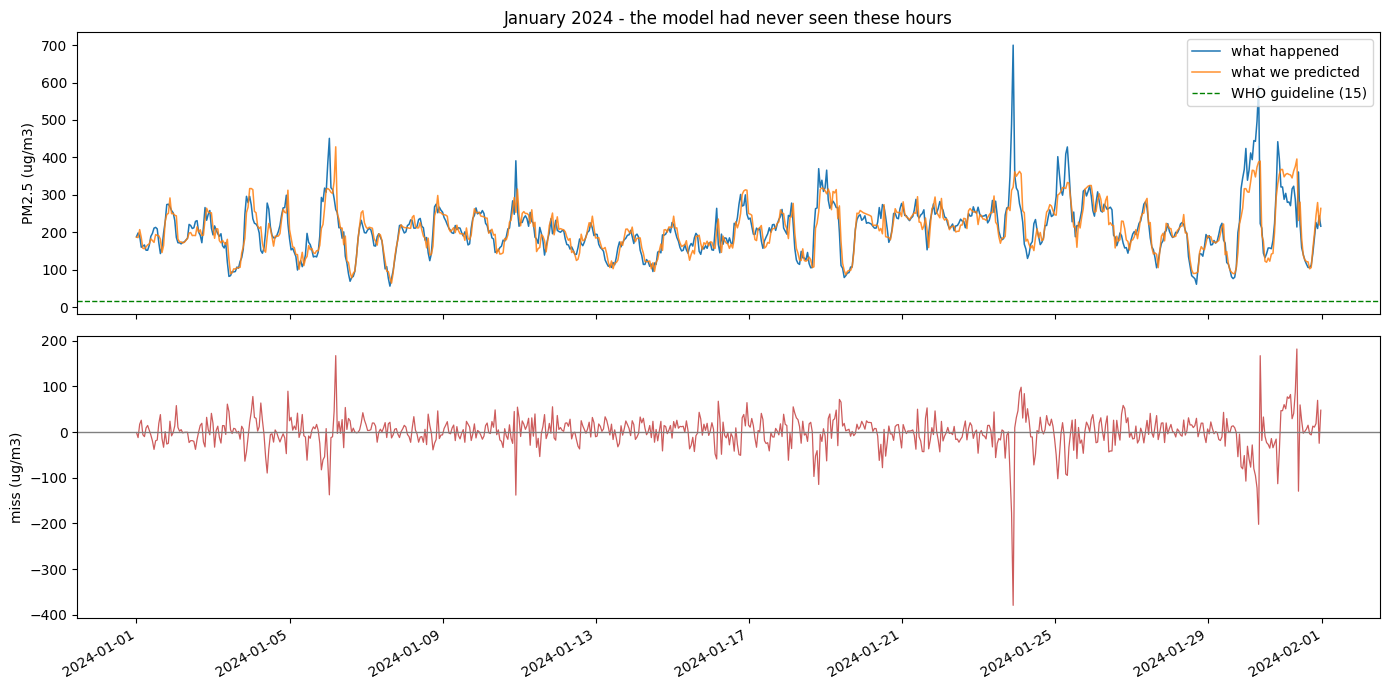

In [69]:
import matplotlib.pyplot as plt

window = (test_pred
          .filter((F.col("ts") >= "2024-01-01") & (F.col("ts") < "2024-02-01"))
          .orderBy("ts")
          .select("ts", "pm25", "prediction")
          .toPandas())

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].plot(window["ts"], window["pm25"], linewidth=1.1, label="what happened")
axes[0].plot(window["ts"], window["prediction"], linewidth=1.1, alpha=0.85,
             label="what we predicted")
axes[0].axhline(15, color="green", linestyle="--", linewidth=1,
                label="WHO guideline (15)")
axes[0].set_ylabel("PM2.5 (ug/m3)")
axes[0].set_title("January 2024 - the model had never seen these hours")
axes[0].legend(loc="upper right")

axes[1].plot(window["ts"], window["prediction"] - window["pm25"],
             linewidth=0.9, color="indianred")
axes[1].axhline(0, color="grey", linewidth=1)
axes[1].set_ylabel("miss (ug/m3)")
axes[1].set_xlabel("")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## Step 35 — Save the models

This is the entire handoff to Phase 2.

Save the whole `PipelineModel`, never the bare estimator. The `VectorAssembler`
and the label indexer have to travel with the trees — without them, a streaming
job receiving raw hourly readings has no way to build the input the model
expects.

In [ ]:
# Save what Step 28 chose, not whichever was trained first.
best_model.write().overwrite().save("models/pm25_v1")
clf_model.write().overwrite().save("models/category_v1")

print(f"regression model saved: {best_name}")

print("saved:")
!ls -d models/*
print()
print("Phase 2 will load these with PipelineModel.load(...) and only ever call")
print(".transform() on them. It never trains.")

### Keep them

Colab wipes its disk when the runtime stops, and these two directories are the
only thing Phase 2 needs. Run this to copy them to Drive.

In [71]:
from google.colab import drive

drive.mount("/content/drive")
!mkdir -p /content/drive/MyDrive/dhaka_pm25
!cp -r models /content/drive/MyDrive/dhaka_pm25/
!ls -R /content/drive/MyDrive/dhaka_pm25/models | head -20

Mounted at /content/drive
/content/drive/MyDrive/dhaka_pm25/models:
category_v1
pm25_v1

/content/drive/MyDrive/dhaka_pm25/models/category_v1:
metadata
stages

/content/drive/MyDrive/dhaka_pm25/models/category_v1/metadata:
part-00000-ca6ba9f8-b286-4fc7-9e8c-f4e543f8d568-c000.txt
_SUCCESS

/content/drive/MyDrive/dhaka_pm25/models/category_v1/stages:
0_strIdx_f912c7b11518
1_VectorAssembler_4d7acdc68481
2_RandomForestClassifier_a208c3cbcb7e

/content/drive/MyDrive/dhaka_pm25/models/category_v1/stages/0_strIdx_f912c7b11518:
data
metadata


---

# Part 3 done

Two trained models, both scored on fifteen months of hours they had never seen.

### What kept these numbers honest

- **The test set was opened once**, in Step 33, after every choice was locked.
  Three model comparisons and two open questions were settled on validation.
- **No input used the current hour.** Rolling windows ended at `-1`; `nowcast`
  only ever appeared lagged.
- **The baselines were real.** Hourly pollution is strongly autocorrelated —
  0.915 at one hour — so "the next hour is the same as this hour" is a genuinely
  hard opponent, not a straw man.
- **The label was built, not borrowed.** Predicting the file's own
  `aqi_category` would have started from 83.4% for free and proved nothing.
- **Per-class F1 was reported**, because only 3% of hours are `Good` and plain
  accuracy would hide a model that never predicts it.

### Coming in Phase 2 — the streaming predictor

```
new hour arrives
      -> build the same features (Part 2 code, unchanged)
      -> PipelineModel.load("models/pm25_v1")
      -> .transform()          PREDICT ONLY, never fit()
      -> write the forecast, raise an alert
```

`pipeline.fit()` on a streaming DataFrame throws — Structured Streaming does not
support training. `.transform()` is supported, which is exactly the split this
project was designed around from the start. The model improves on a separate
schedule: the stream writes its predictions out, the batch trainer reads that
accumulated history later and produces `v2`, and the running stream picks it up
mid-flight through a version marker.